## Exploratory Data Analysis (EDA)

### Objective
This notebook performs comprehensive exploratory data analysis of the Rheumatoid Arthritis (RA) dataset to understand the characteristics of patients, disease metrics, treatments, and their relationships with flare outcomes. Key analyses include:

- **Data Cleaning**: Remove patients without DAS28 scores and exclude features with >50% missingness
- **Missingness Patterns**: Analyze missing data distribution and assess whether missingness is related to flare outcomes
- **Target Distribution**: Examine class balance in the flare_next_visit outcome variable
- **Longitudinal Structure**: Characterize visit frequency and follow-up patterns across patients
- **Univariate Analysis**:
  - **Continuous variables**: DAS28 score, CRP, ESR, disease duration, days since last visit, age at visit
  - **Categorical variables**: Gender, csDMARD medications, b/ts DMARD medications
  - **Treatment Doses**: MTX dose categories, steroid dose categories with association to flare outcomes
  - **Comorbidities**: Prevalence and relationship of cardiovascular, metabolic, respiratory, and other comorbidities to flare risk
- **Bivariate Analysis**: Relationships between clinical variables (DAS28, CRP, ESR, treatment doses, disease duration) and flare outcomes using boxplots, violin plots, histograms, and swarmplots
- **Outcome Associations**: Examine how previous flare history and other categorical variables predict next-visit flare

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu
import sys
from os import path, replace
import numpy as np
from scipy.stats import shapiro


project_root = path.abspath(path.join('..'))

if project_root not in sys.path:
    sys.path.append(project_root)
    
from src.preprocessing import preprocess_data
file_path = r"../data/RA_Dataset.xlsx"
output_path = r"../data/RA_dataset_cleaned.csv"

df_all=preprocess_data(file_path)

#drop rows where target variable is missing (the last visit of each patient)
df_cleaned = df_all.dropna(subset=["flare_next_visit"]).copy()
df_cleaned['flare_next_visit'] = df_cleaned['flare_next_visit'].astype(int)

df_cleaned.to_csv(output_path, index=False)

%matplotlib inline
sns.set_style("whitegrid")

Dropping columns with > 50% missing values: smoking, tjc_28, sjc_28, vas


Variables with more than 50% missing values were identified and excluded from further analysis. The table below shows these variables and their percentage of missingness. Additionally, TJC_28 and SJC_28 were also excluded due to their high correlation with DAS28, which has lower missingness.

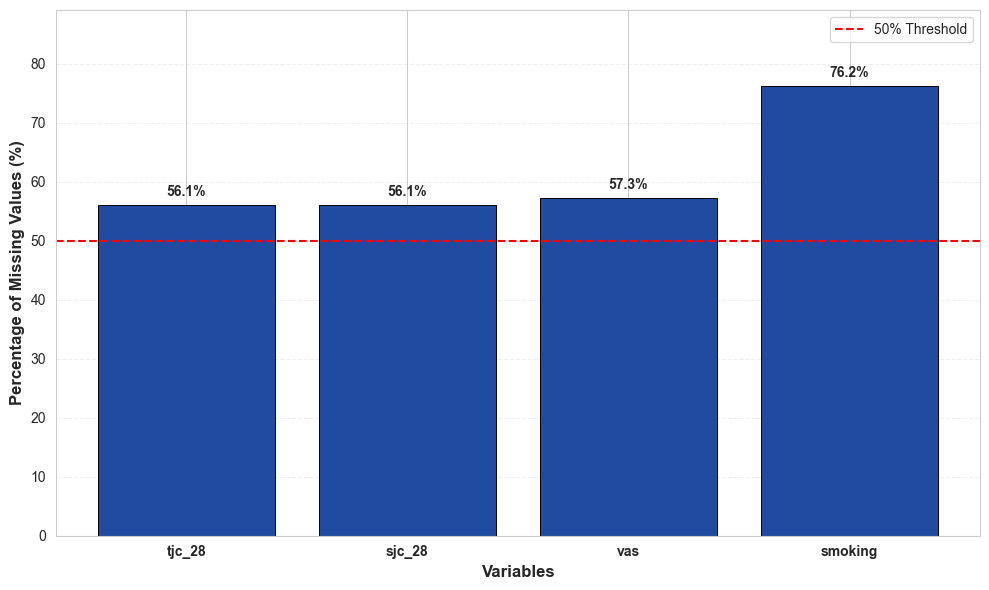

In [5]:
from src.preprocessing import handle_categorical_missing, load_data

df_raw = load_data(file_path)
handle_categorical_missing(df_raw)

missing_percent = (df_raw.isnull().mean() * 100).sort_values(ascending=True)
high_missing = missing_percent[missing_percent > 50]

plt.figure(figsize=(10, 6))
bars = plt.bar(high_missing.index, high_missing.values, color="#204BA1", edgecolor='black', linewidth=0.7)

# Add percentage labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.axhline(50, color='red', linestyle='--', linewidth=1.5, label='50% Threshold')
plt.xlabel('Variables', fontsize=12, fontweight='bold')
plt.ylabel('Percentage of Missing Values (%)', fontsize=12, fontweight='bold')
#plt.title('Variables Excluded Due to High Missingness', fontsize=13, fontweight='bold', pad=15)
plt.xticks(ha='center', fontsize=10, fontweight='bold')
plt.yticks(fontsize=10)
plt.ylim(0, max(high_missing.values) * 1.17)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

#### Dataset Overview

In [6]:
df_cleaned.shape

(393, 49)

In [7]:
df_cleaned.head(10)

,patient_id,gender,year_of_diagnosis,rf_status,anti_ccp_status,comorbidities,visit_date,visit_type,crp,crp_upper_limit,...,comorb_gastrointestinal_hepatic,comorb_malignancy,comorb_musculoskeletal,comorb_neurologic_psychiatric,comorb_autoimmune_other,comorbidity_count,csdmard_use,b_ts_dmard_use,steroid_use,treatment_count
0,RA001,1,1997,0,0,"depression,hypothyroidism",2017-12-18,Baseline,0.40,0.5,...,0,0,0,1,0,2,1,1,0,3
1,RA001,1,1997,0,0,"depression,hypothyroidism",2018-03-20,Follow-up,0.40,0.5,...,0,0,0,1,0,2,1,0,0,2
2,RA001,1,1997,0,0,"depression,hypothyroidism",2018-09-25,Follow-up,0.40,0.5,...,0,0,0,1,0,2,0,1,0,1
4,RA002,1,1999,0,0,,2023-10-27,Baseline,0.02,0.5,...,0,0,0,0,0,0,1,1,0,3
5,RA002,1,1999,0,0,,2024-01-30,Follow-up,0.07,0.5,...,0,0,0,0,0,0,1,1,0,2
6,RA002,1,1999,0,0,,2024-04-23,Follow-up,1.90,5.0,...,0,0,0,0,0,0,1,1,0,2
7,RA002,1,1999,0,0,,2024-09-17,Follow-up,0.10,0.5,...,0,0,0,0,0,0,1,1,0,2
9,RA003,0,2005,1,1,transient ischemic attack,2023-09-01,Baseline,0.46,0.5,...,0,0,0,0,0,1,0,0,0,0
11,RA004,0,2016,1,1,chronic obstructive pulmonary disease,2016-05-16,Baseline,NaN,NaN,...,0,0,0,0,0,1,1,0,1,3
12,RA004,0,2016,1,1,chronic obstructive pulmonary disease,2016-09-20,Follow-up,6.60,5.0,...,0,0,0,0,0,1,1,0,1,2


In [8]:
df_cleaned.columns.to_list()

['patient_id',
 'gender',
 'year_of_diagnosis',
 'rf_status',
 'anti_ccp_status',
 'comorbidities',
 'visit_date',
 'visit_type',
 'crp',
 'crp_upper_limit',
 'esr',
 'das28_score',
 'csdmard_name',
 'mtx_use',
 'mtx_dose',
 'b_ts_dmard_name',
 'steroid_dose',
 'treatment_decision',
 'switch_reason',
 'flare_event',
 'source',
 'treatment_decision_grouped',
 'birth_year',
 'days_since_last_visit',
 'disease_duration',
 'age_at_visit',
 'das28_change',
 'steroid_dose_category',
 'mtx_dose_category',
 'previous_flare',
 'flare_next_visit',
 'crp_missing',
 'esr_missing',
 'crp_normalized',
 'inflammation_flag',
 'comorb_cardiovascular',
 'comorb_metabolic_endocrine',
 'comorb_respiratory',
 'comorb_renal_urological',
 'comorb_gastrointestinal_hepatic',
 'comorb_malignancy',
 'comorb_musculoskeletal',
 'comorb_neurologic_psychiatric',
 'comorb_autoimmune_other',
 'comorbidity_count',
 'csdmard_use',
 'b_ts_dmard_use',
 'steroid_use',
 'treatment_count']

In [9]:
df_cleaned.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
Index: 393 entries, 0 to 497
Data columns (total 49 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   patient_id                       393 non-null    str           
 1   gender                           393 non-null    Int64         
 2   year_of_diagnosis                391 non-null    Int64         
 3   rf_status                        390 non-null    Int64         
 4   anti_ccp_status                  390 non-null    Int64         
 5   comorbidities                    393 non-null    str           
 6   visit_date                       393 non-null    datetime64[us]
 7   visit_type                       393 non-null    str           
 8   crp                              326 non-null    float64       
 9   crp_upper_limit                  326 non-null    float64       
 10  esr                              361 non-null    float64       
 11  das28_sco

#### Missingness

In [10]:
#Missinness if patients without DAS28 scores are excluded

patients_no_das28 = df_cleaned.groupby('patient_id')['das28_score'].apply(lambda x: x.isna().all())
patients_no_das28 = patients_no_das28.index[patients_no_das28].tolist()
df_das28 = df_cleaned[~df_cleaned["patient_id"].isin(patients_no_das28)].copy()
df_das28["patient_id"].nunique()

missing_count = df_das28.isnull().sum()
missing_percentage = (df_das28.isnull().mean() * 100).round(1)

#Summary Table
missing_table = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percentage': missing_percentage
    }).sort_values(by='missing_percentage', ascending=False)

missing_table[missing_table['missing_percentage'] > 0]


,missing_count,missing_percentage
das28_change,104,30.3
das28_score,95,27.7
crp_upper_limit,61,17.8
crp_normalized,61,17.8
crp,61,17.8
esr,25,7.3
rf_status,3,0.9
anti_ccp_status,3,0.9
year_of_diagnosis,2,0.6
disease_duration,2,0.6


In [11]:
patient_complete = df_cleaned.groupby("patient_id").apply(lambda x: x.notna().all().all())

#patients with complete data
complete_patients = patient_complete[patient_complete].index.tolist()

print("Number of patients with complete data:", len(complete_patients))

Number of patients with complete data: 22


In [12]:
missing_count = df_cleaned.isnull().sum()
missing_percentage = (df_cleaned.isnull().mean() * 100).round(1)

#Summary Table
missing_table = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percentage': missing_percentage
    }).sort_values(by='missing_percentage', ascending=False)

missing_table[missing_table['missing_percentage'] > 0]

,missing_count,missing_percentage
das28_score,145,36.9
das28_change,134,34.1
crp_upper_limit,67,17.0
crp_normalized,67,17.0
crp,67,17.0
esr,32,8.1
rf_status,3,0.8
anti_ccp_status,3,0.8
year_of_diagnosis,2,0.5
disease_duration,2,0.5


In [13]:
print("Rows before:", df_cleaned.shape[0])
print("Rows after:", df_das28.shape[0])
print("Rows removed:", df_cleaned.shape[0] - df_das28.shape[0])

Rows before: 393
Rows after: 343
Rows removed: 50


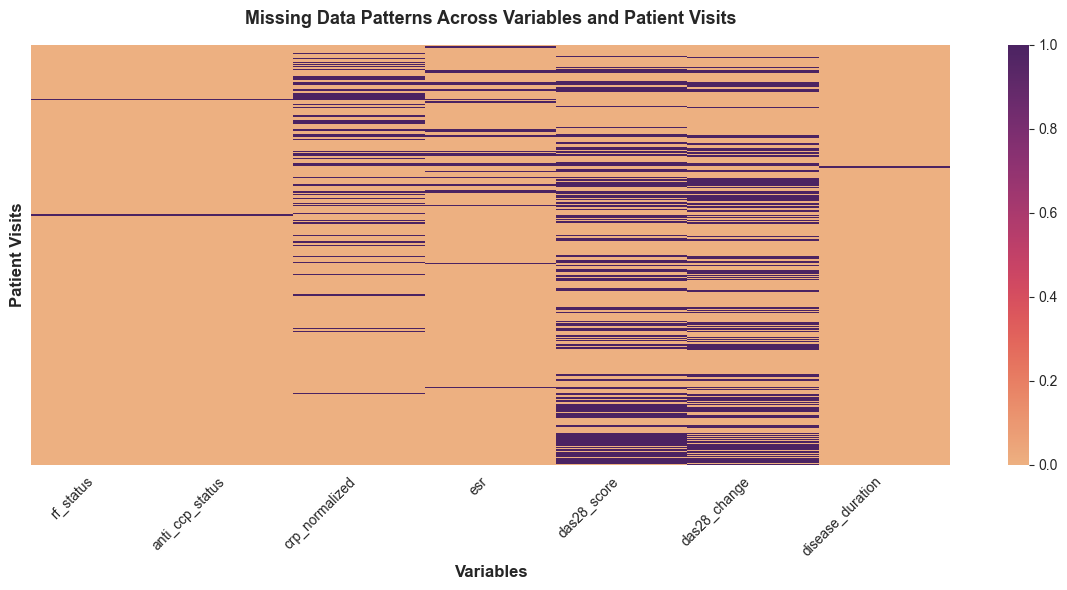

In [14]:
#Heatmap of missing data patterns for the dataset's variables

missing_data_variables = [
    'rf_status',
    'anti_ccp_status',
    'crp_normalized',
    'esr',
    'das28_score',
    'das28_change',
    'disease_duration'
]

plt.figure(figsize=(12, 6))
sns.heatmap(df_cleaned[list(missing_data_variables)].isnull(), cbar=True, cmap='flare', yticklabels=False)
plt.title('Missing Data Patterns Across Variables and Patient Visits', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Variables', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Patient Visits', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

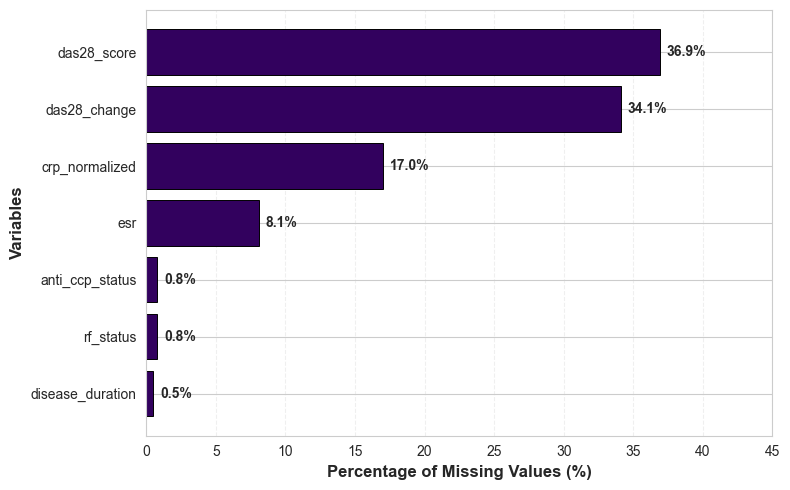

In [15]:
# Barplot of missing percentages
plt.figure(figsize=(8, 5))

missing_plot = (missing_table.loc[missing_table.index.isin(missing_data_variables)]
                .sort_values(by='missing_percentage', ascending=True))
bars = plt.barh(missing_plot.index, missing_plot['missing_percentage'], color="#32015EFF", edgecolor='black', linewidth=0.7)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{width:.1f}%', va='center', fontweight='bold', fontsize=10)

plt.xlabel('Percentage of Missing Values (%)', fontsize=12, fontweight='bold')
plt.ylabel('Variables', fontsize=12, fontweight='bold')
plt.gca().tick_params(axis='x', labelsize=10)
plt.gca().tick_params(axis='y', labelsize=10)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.xlim(0, 45)

plt.tight_layout()
plt.show()

In [16]:
crp_counts = pd.crosstab(df_cleaned['crp_missing'], df_cleaned['flare_next_visit'], 
            rownames=['CRP missing'], colnames=['Flare next visit'])


crp_percent = pd.crosstab(df_cleaned["crp_missing"], df_cleaned["flare_next_visit"], normalize="index", 
            rownames=["CRP missing"], colnames=["Flare next visit"]).round(2)

display(crp_counts)
display(crp_percent)

Flare next visit,0,1
CRP missing,,
0,221,105
1,42,25


Flare next visit,0,1
CRP missing,,
0,0.68,0.32
1,0.63,0.37


In [17]:
esr_counts = pd.crosstab(df_cleaned['esr_missing'], df_cleaned['flare_next_visit'], 
            rownames=['ESR missing'], colnames=['Flare next visit'])


esr_percent = pd.crosstab(df_cleaned["esr_missing"], df_cleaned["flare_next_visit"], normalize="index", 
            rownames=["ESR missing"], colnames=["Flare next visit"]).round(2)

display(esr_counts)
display(esr_percent)

Flare next visit,0,1
ESR missing,,
0,240,121
1,23,9


Flare next visit,0,1
ESR missing,,
0,0.66,0.34
1,0.72,0.28


In [18]:
df_cleaned['das28_missing'] = df_cleaned['das28_change'].isnull().astype(int)

das28_counts = pd.crosstab(df_cleaned['das28_missing'], df_cleaned['flare_next_visit'], 
            rownames=['DAS28 Missing'], colnames=['Flare next visit'])

das28_percent = pd.crosstab(df_cleaned["das28_missing"], df_cleaned["flare_next_visit"], normalize="index", 
            rownames=["DAS28 Missing"], colnames=["Flare next visit"]).round(2)

display(das28_counts)
display(das28_percent)

Flare next visit,0,1
DAS28 Missing,,
0,172,87
1,91,43


Flare next visit,0,1
DAS28 Missing,,
0,0.66,0.34
1,0.68,0.32


In [19]:
# Chi-Square Test for CRP Missingness
contingency_table_crp = pd.crosstab(df_cleaned['crp_missing'], df_cleaned['flare_next_visit'])
chi2_crp, p_crp, dof_crp, expected_crp = chi2_contingency(contingency_table_crp)
print(f"Chi-Square Test for CRP Missingness:")
print(f"Chi2 Statistic: {chi2_crp:.4f}, p-value: {p_crp:.4f}")
print("Expected Frequencies:")
print(expected_crp)

# Chi-Square Test for ESR Missingness
contingency_table_esr = pd.crosstab(df_cleaned['esr_missing'], df_cleaned['flare_next_visit'])
chi2_esr, p_esr, dof_esr, expected_esr = chi2_contingency(contingency_table_esr)
print(f"\nChi-Square Test for ESR Missingness:")
print(f"Chi2 Statistic: {chi2_esr:.4f}, p-value: {p_esr:.4f}")
print("Expected Frequencies:")
print(expected_esr)

# Chi-Square Test for DAS28 Missingness
contingency_table_das28 = pd.crosstab(df_cleaned['das28_missing'], df_cleaned['flare_next_visit'])
chi2_das28, p_das28, dof_das28, expected_das28 = chi2_contingency(contingency_table_das28)
print(f"\nChi-Square Test for DAS28 Missingness:")
print(f"Chi2 Statistic: {chi2_das28:.4f}, p-value: {p_das28:.4f}")
print("Expected Frequencies:")
print(expected_das28)

Chi-Square Test for CRP Missingness:
Chi2 Statistic: 0.4440, p-value: 0.5052
Expected Frequencies:
[[218.16284987 107.83715013]
 [ 44.83715013  22.16284987]]

Chi-Square Test for ESR Missingness:
Chi2 Statistic: 0.1810, p-value: 0.6705
Expected Frequencies:
[[241.58524173 119.41475827]
 [ 21.41475827  10.58524173]]

Chi-Square Test for DAS28 Missingness:
Chi2 Statistic: 0.0349, p-value: 0.8519
Expected Frequencies:
[[173.32569975  85.67430025]
 [ 89.67430025  44.32569975]]


### Target Analysis


In [20]:
# Percentages of target variable
df_cleaned["flare_next_visit"].value_counts(normalize=True, dropna=False) * 100

flare_next_visit
0    66.92112
1    33.07888
Name: proportion, dtype: float64

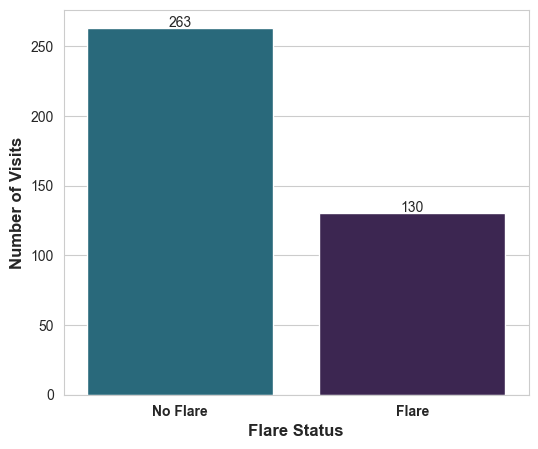

In [21]:
# Counts of target variable
plt.figure(figsize=(6, 5))
graph = sns.countplot(x='flare_next_visit', data=df_cleaned, 
                      hue= 'flare_next_visit', palette= ["#1B7189", "#3C1F58"], legend=False)
#plt.title('Distribution of Flare Outcomes at Next Visit', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Flare Status', fontsize=12, fontweight='bold')
plt.ylabel('Number of Visits', fontsize=12, fontweight='bold')
plt.xticks(ticks=[0, 1], labels=['No Flare', 'Flare'], fontsize=10, fontweight='bold')


for p in graph.patches: 
    bar = p
    if isinstance(bar, Rectangle):
        height = bar.get_height()
        graph.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{int(height)}",
        ha='center'      
    )
plt.show()

In [22]:
# One row per patient: first recorded visit
baseline = df_all.sort_values(["patient_id", "visit_date"]) \
                     .groupby("patient_id", as_index=False) \
                     .head(1)

# Mean ± SD
def mean_sd(series):
    return f"{series.mean():.1f} ± {series.std():.1f}"

# Median (IQR)
def median_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    return f"{series.median():.2f} ({q1:.2f}–{q3:.2f})"

def n_percent(series, value=1):
    n = (series == value).sum()
    total = series.notna().sum()
    return f"{n} ({100*n/total:.1f}%)"

visits_per_patient = df_all.groupby("patient_id").size()

baseline_stats = {
    'Age at first visit': mean_sd(baseline["age_at_visit"]),
    'Disease duration': median_iqr(baseline["disease_duration"]),
    'DAS28 score': mean_sd(baseline["das28_score"].dropna()),
    'CRP normalized': median_iqr(baseline["crp_normalized"].dropna()),
    'ESR (mm/hr)': median_iqr(baseline["esr"].dropna()),
    'Female': n_percent(baseline["gender"], 1),
    'Male': n_percent(baseline["gender"], 0),
    'RF positive': n_percent(baseline["rf_status"], 1),
    'Anti-CCP positive': n_percent(baseline["anti_ccp_status"], 1),
    'Patients with ≥1 comorbidity': n_percent(baseline["comorbidity_count"] >= 1, True),
    'Visits per patient': median_iqr(visits_per_patient)
}

baseline_characteristics = pd.DataFrame(list(baseline_stats.items()), columns=['Characteristic', 'Value'])
baseline_characteristics

,Characteristic,Value
0,Age at first visit,60.5 ± 11.5
1,Disease duration,4.00 (0.00–14.00)
2,DAS28 score,3.9 ± 1.3
3,CRP normalized,0.92 (0.41–2.12)
4,ESR (mm/hr),25.00 (16.00–37.00)
5,Female,83 (78.3%)
6,Male,23 (21.7%)
7,RF positive,54 (51.9%)
8,Anti-CCP positive,64 (61.5%)
9,Patients with ≥1 comorbidity,84 (79.2%)


In [23]:
#time varying variables
time_varying_variables = {
    'Days since last visit': median_iqr(df_cleaned["days_since_last_visit"]),
    'DAS28 score': mean_sd(df_cleaned["das28_score"]),
    'Das28 change': mean_sd(df_cleaned["das28_change"]),
    'CRP normalized': median_iqr(df_cleaned["crp_normalized"]),
    'ESR (mm/hr)': median_iqr(df_cleaned["esr"]),
    'MTX use': n_percent(df_cleaned["mtx_use"], 1),
    'csDMARD use': n_percent(df_cleaned["csdmard_use"], 1),
    'b_ts_DMARD use': n_percent(df_cleaned["b_ts_dmard_use"], 1),
    'Corticosteroid use': n_percent(df_cleaned["steroid_use"], 1),
    'Treatment count': median_iqr(df_cleaned["treatment_count"]),
    'Previous flare': n_percent(df_cleaned["previous_flare"], 1)

}
time_varying_characteristics = pd.DataFrame(list(time_varying_variables.items()), columns=['Characteristic', 'Value'])
time_varying_characteristics

,Characteristic,Value
0,Days since last visit,127.00 (0.00–238.00)
1,DAS28 score,3.4 ± 1.2
2,Das28 change,-0.1 ± 0.9
3,CRP normalized,0.63 (0.26–1.60)
4,ESR (mm/hr),20.00 (11.00–35.00)
5,MTX use,219 (55.7%)
6,csDMARD use,223 (56.7%)
7,b_ts_DMARD use,160 (40.7%)
8,Corticosteroid use,148 (37.7%)
9,Treatment count,2.00 (1.00–3.00)


### Visits per patient

In [24]:
#average visits per patient
visits_per_patient.describe()

count    106.000000
mean       4.707547
std        2.559639
min        2.000000
25%        3.000000
50%        4.000000
75%        6.000000
max       16.000000
dtype: float64

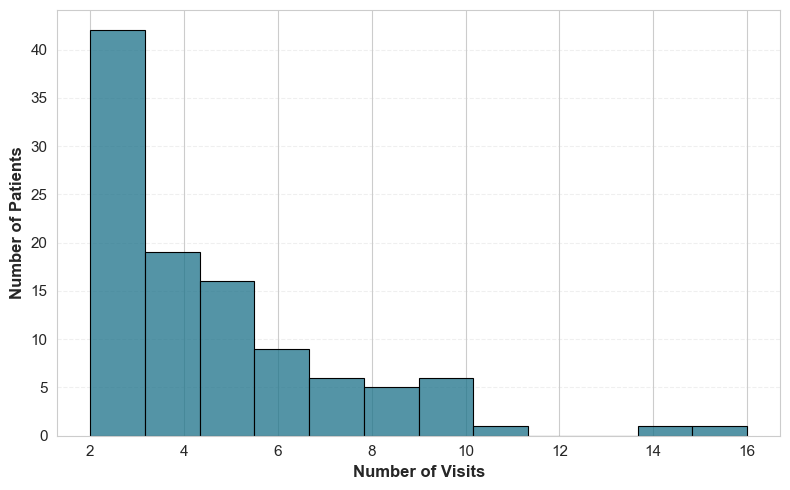

In [25]:
plt.figure(figsize=(8, 5))
sns.histplot(
    x=visits_per_patient,
    bins=12,
    color="#1B7189",
    edgecolor="black",
    linewidth=0.8
)
# plt.title('Distribution of Visits per Patient', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Number of Visits', fontsize=12, fontweight='bold')
plt.ylabel('Number of Patients', fontsize=12, fontweight='bold')
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

## Univariate Analysis
### Continuous variables


In [26]:
df_cleaned['das28_score'].describe()

count    248.000000
mean       3.404194
std        1.233597
min        1.030000
25%        2.415000
50%        3.355000
75%        4.200000
max        6.800000
Name: das28_score, dtype: float64

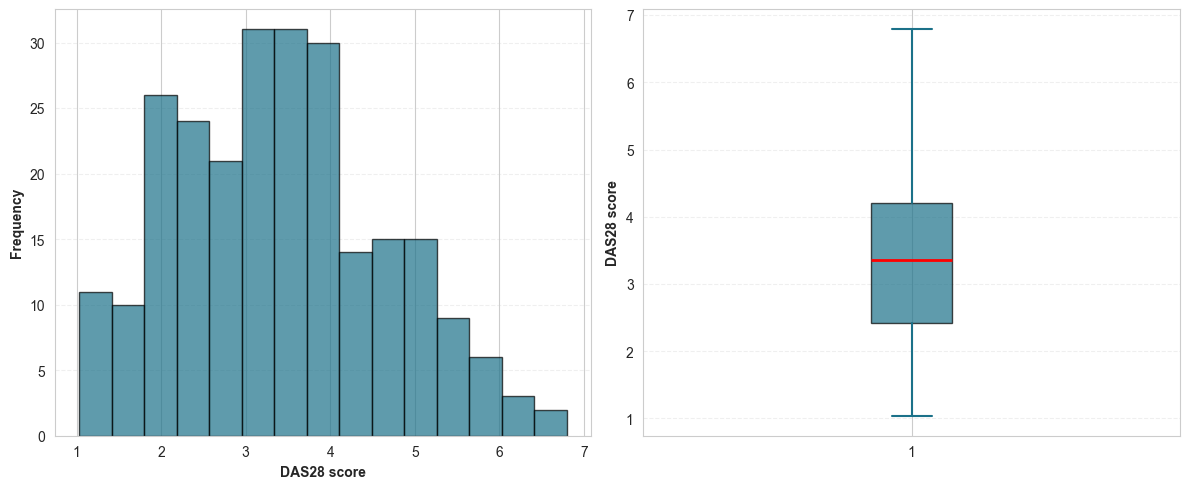

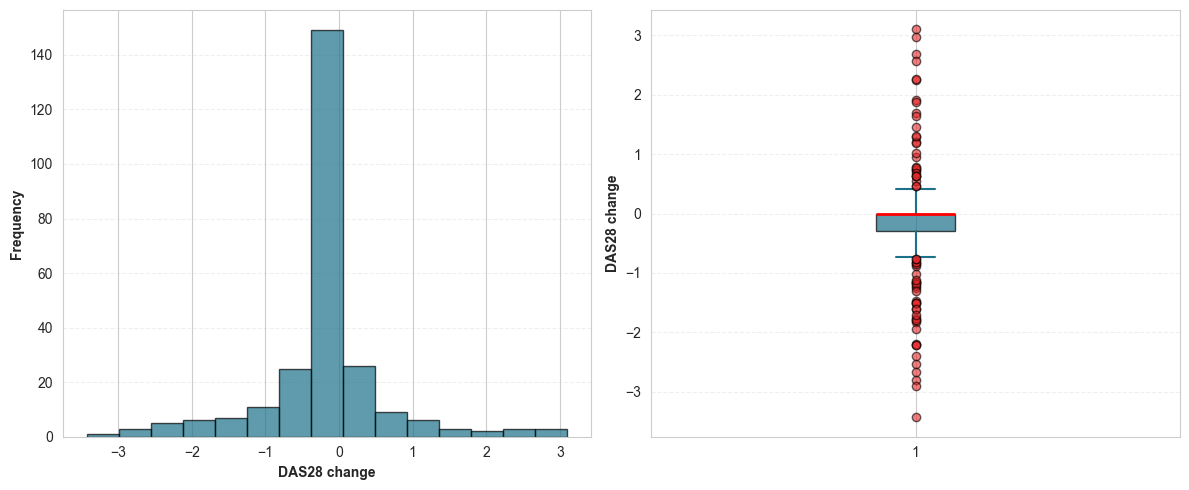

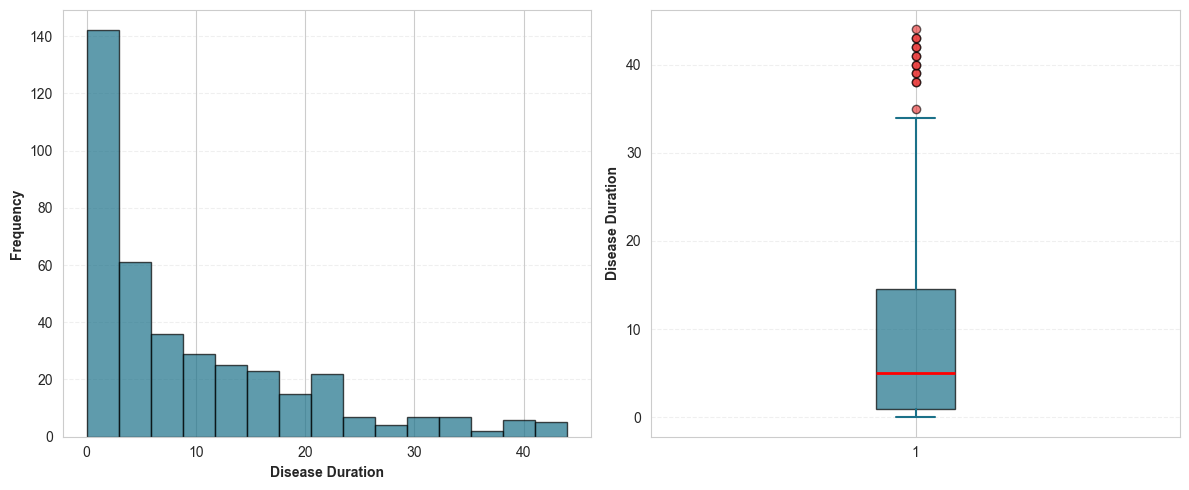

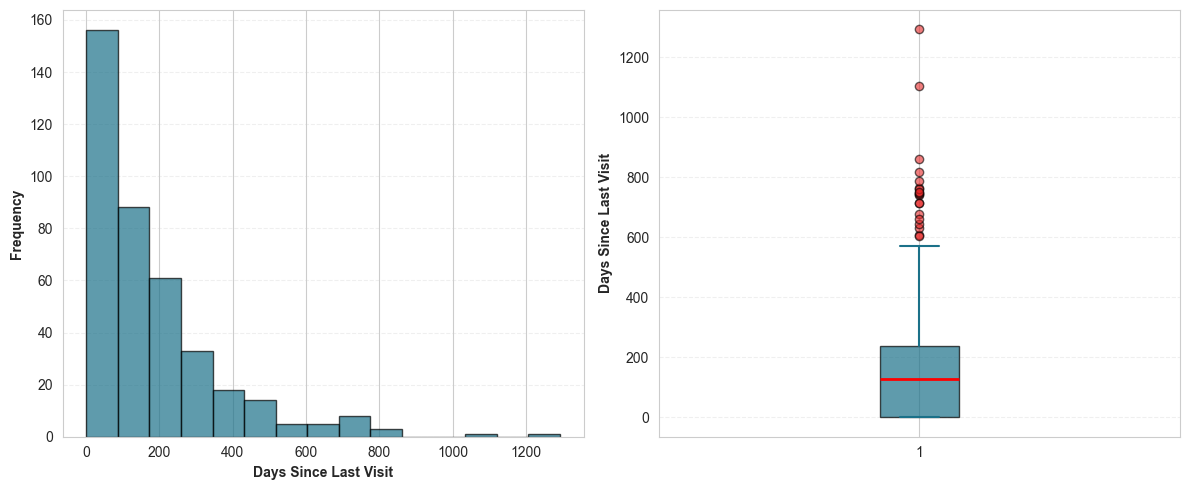

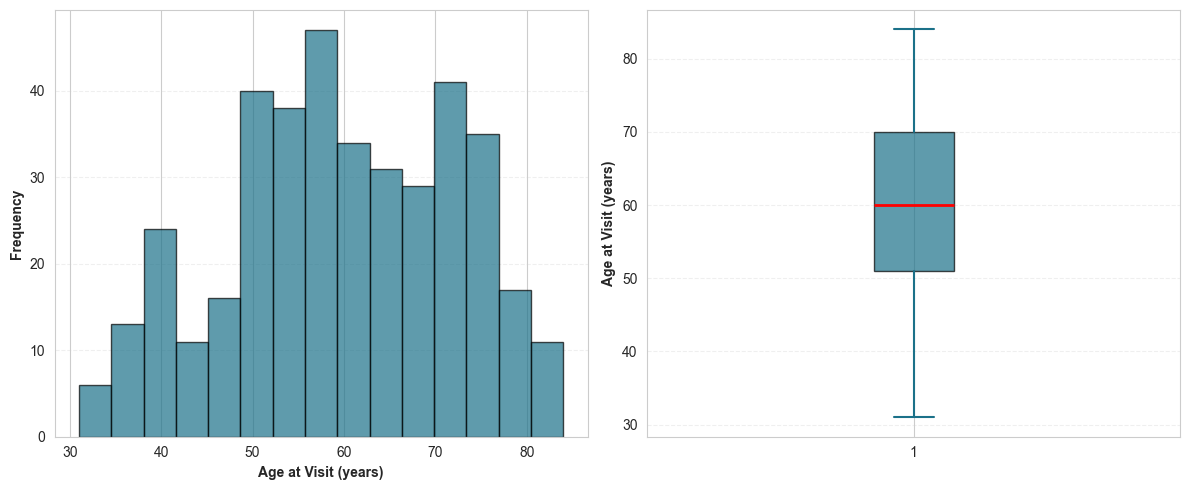

In [27]:
continuous_variables = {
    'DAS28 score': df_cleaned['das28_score'],
    'DAS28 change': df_cleaned['das28_change'],
    'Disease Duration': df_cleaned['disease_duration'],
    'Days Since Last Visit': df_cleaned['days_since_last_visit'],
    'Age at Visit (years)': df_cleaned['age_at_visit']
}

for col_name, col_data in continuous_variables.items():
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    #Histogram
    axes[0].hist(
        col_data.dropna(),
        bins=15,
        color="#1B7189",
        edgecolor='black',
        alpha=0.7
    )
    # axes[0].set_title(f'Distribution of {col_name}', fontweight='bold', fontsize=12)
    axes[0].set_xlabel(col_name, fontweight='bold')
    axes[0].set_ylabel('Frequency', fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3, linestyle='--')
    
    #Boxplot
    bp = axes[1].boxplot(col_data.dropna(), vert=True, patch_artist=True)
    
    #Color the box
    bp['boxes'][0].set_facecolor('#1B7189')
    bp['boxes'][0].set_alpha(0.7)
    
    #Style whiskers, caps, and medians
    for whisker in bp['whiskers']:
        whisker.set(linewidth=1.5, color='#1B7189')
    for cap in bp['caps']:
        cap.set(linewidth=1.5, color='#1B7189')
    for median in bp['medians']:
        median.set(linewidth=2, color='red')
    
    #Style outliers
    for flier in bp['fliers']:
        flier.set(marker='o', markerfacecolor='#e72828', markersize=6, alpha=0.6)
    # axes[1].set_title(f'Boxplot of {col_name}', fontweight='bold', fontsize=12)
    axes[1].set_ylabel(col_name, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()

In [28]:
df_cleaned['esr'].skew()

np.float64(1.5404135838202748)

In [29]:
df_cleaned['crp_normalized'].skew()

np.float64(4.951418804605117)

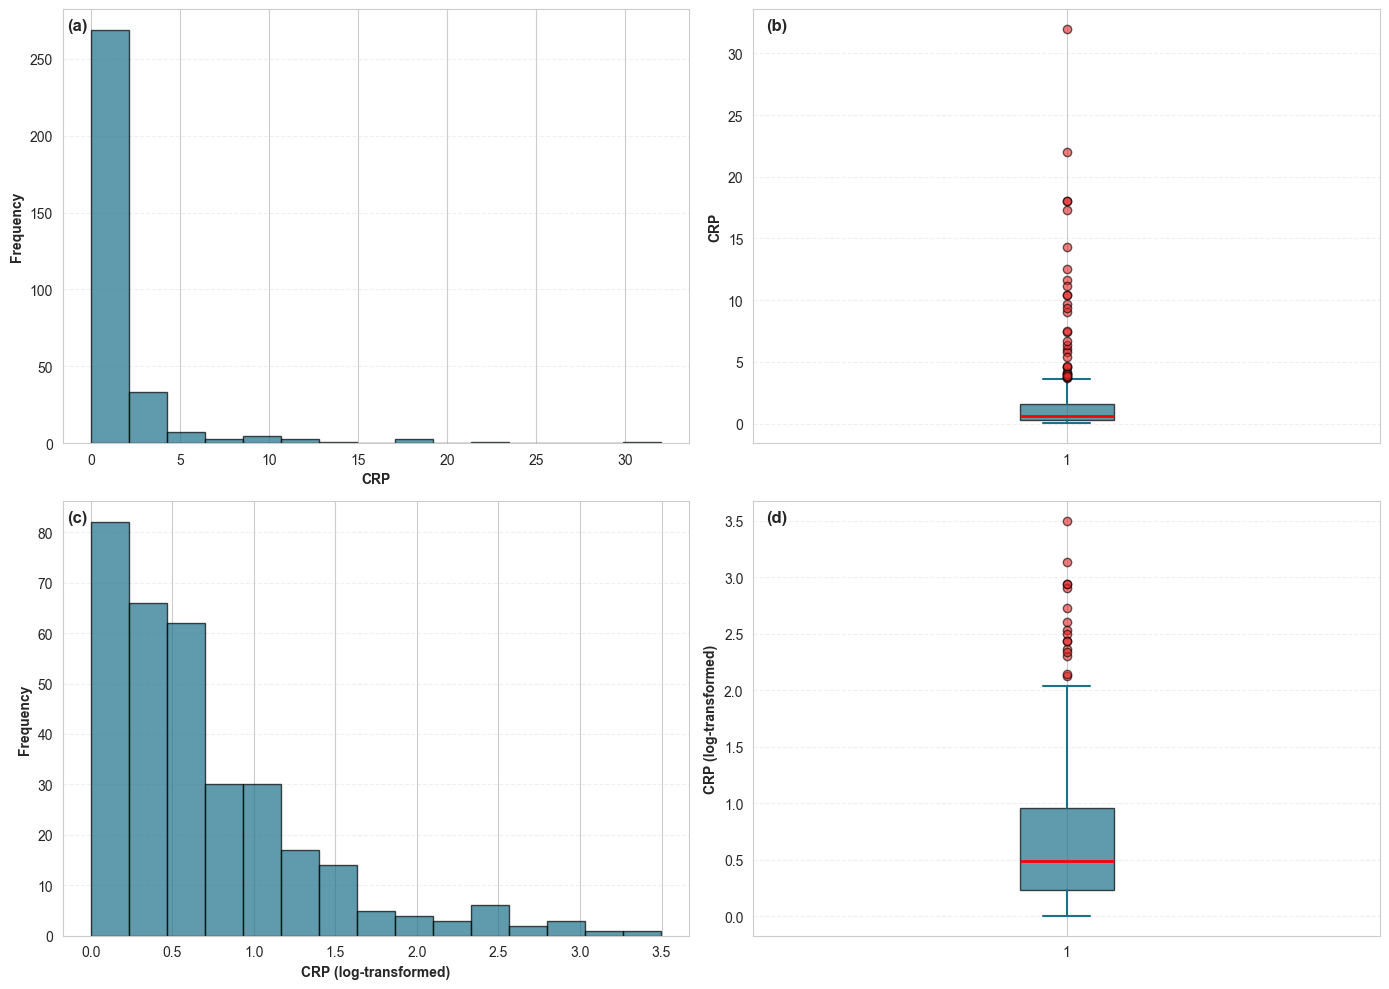

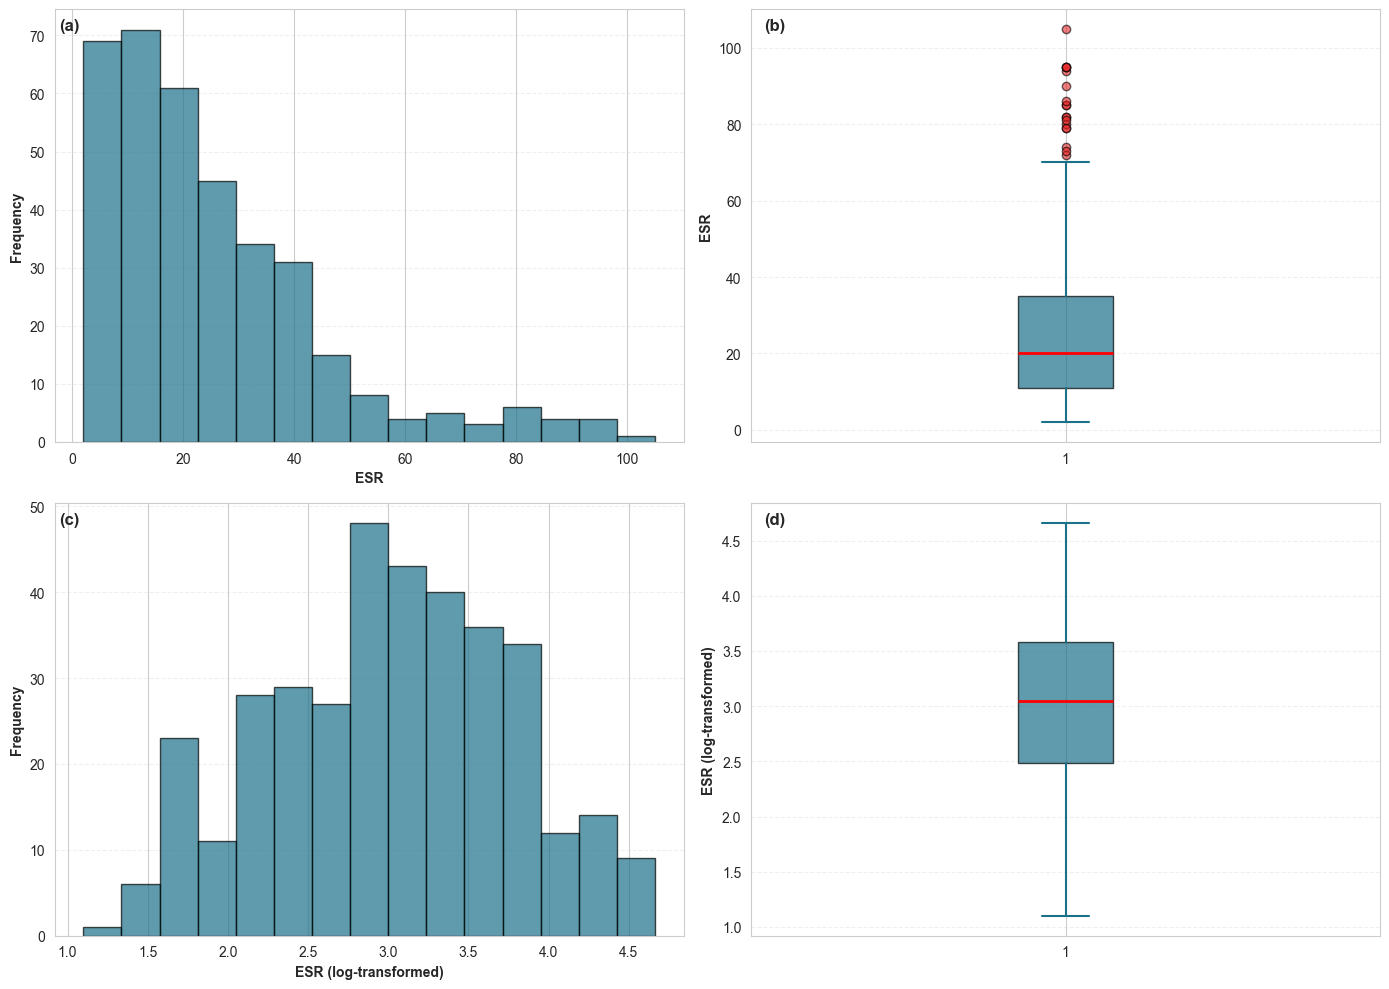

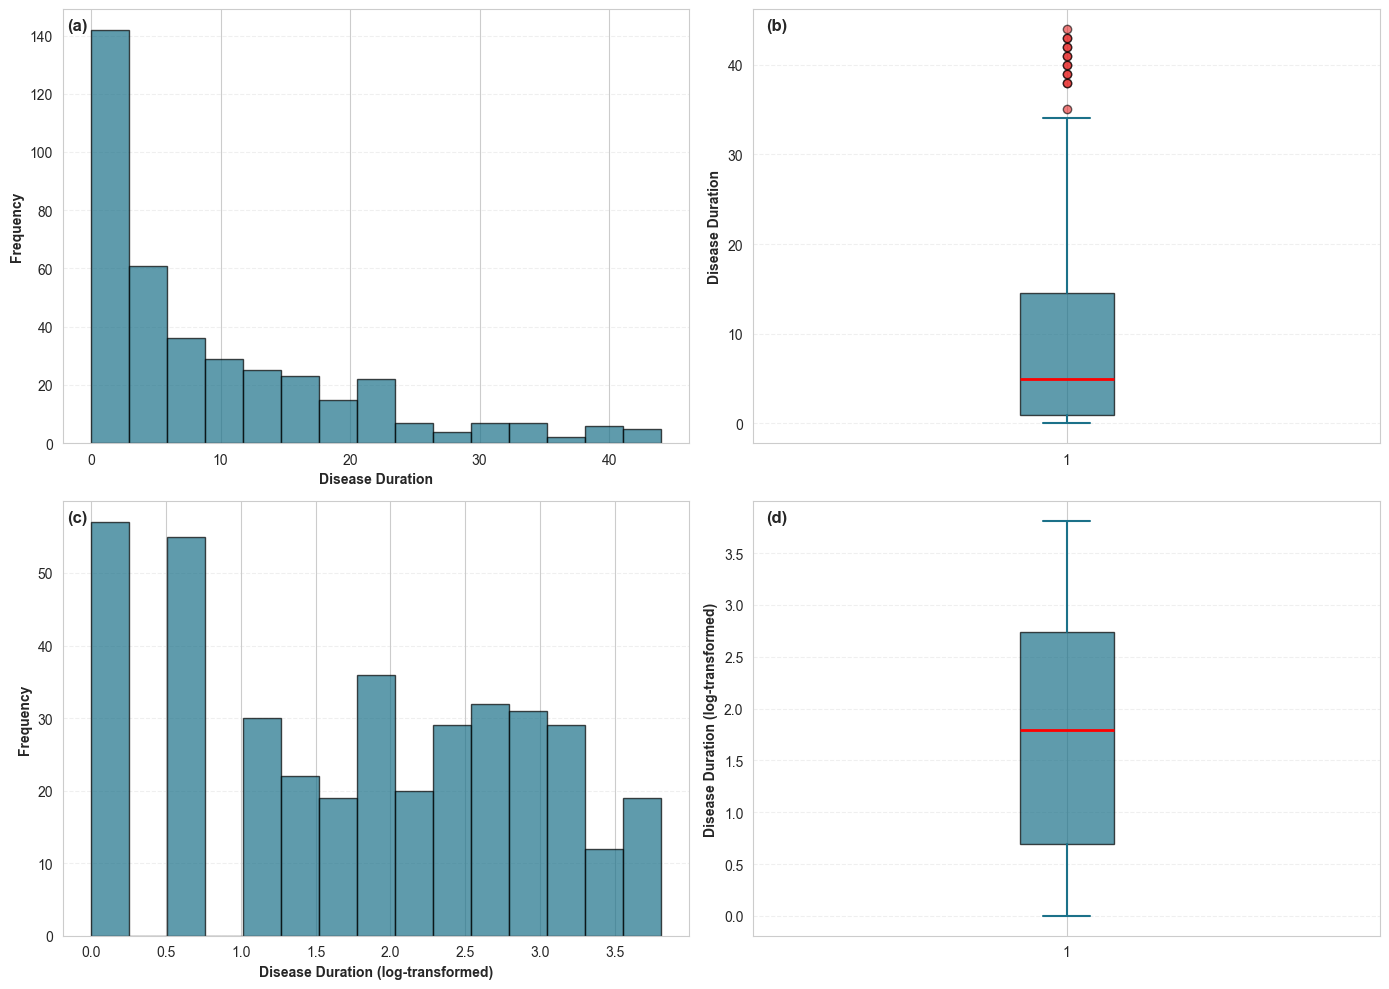

In [30]:
# CRP and ESR Comparison (Original vs Log-Transformed)
df_cleaned['log_crp_normalized'] = np.log1p(df_cleaned['crp_normalized'])
df_cleaned['log_esr'] = np.log1p(df_cleaned['esr'])
df_cleaned['log_disease_duration'] = np.log1p(df_cleaned['disease_duration'])

variables = [
    ('CRP', 'crp_normalized', 'log_crp_normalized'),
    ('ESR', 'esr', 'log_esr'),
    ('Disease Duration', 'disease_duration', 'log_disease_duration')
]

for var_name, col_orig, col_log in variables:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    #Original variables
    
    #Histogram
    axes[0, 0].hist(
        df_cleaned[col_orig].dropna(),
        bins=15,
        color="#1B7189",
        edgecolor='black',
        alpha=0.7
    )
    axes[0, 0].set_xlabel(var_name, fontweight='bold')
    axes[0, 0].set_ylabel('Frequency', fontweight='bold')
    axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')
    axes[0, 0].text(0.0075, 0.98, '(a)', transform=axes[0, 0].transAxes, fontsize=12, fontweight='bold', 
                    verticalalignment='top')
    
    #Boxplot
    bp1 = axes[0, 1].boxplot(df_cleaned[col_orig].dropna(), vert=True, patch_artist=True)
    bp1['boxes'][0].set_facecolor('#1B7189')
    bp1['boxes'][0].set_alpha(0.7)
    for whisker in bp1['whiskers']:
        whisker.set(linewidth=1.5, color='#1B7189')
    for cap in bp1['caps']:
        cap.set(linewidth=1.5, color='#1B7189')
    for median in bp1['medians']:
        median.set(linewidth=2, color='red')
    for flier in bp1['fliers']:
        flier.set(marker='o', markerfacecolor='#e72828', markersize=6, alpha=0.6)
    axes[0, 1].set_ylabel(var_name, fontweight='bold')
    axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--')
    axes[0, 1].text(0.02, 0.98, '(b)', transform=axes[0, 1].transAxes, fontsize=12, fontweight='bold', 
                    verticalalignment='top')
    
    #Log transformed variables
    #Histogram
    axes[1, 0].hist(
        df_cleaned[col_log].dropna(),
        bins=15,
        color="#1B7189",
        edgecolor='black',
        alpha=0.7
    )
    axes[1, 0].set_xlabel(f'{var_name} (log-transformed)', fontweight='bold')
    axes[1, 0].set_ylabel('Frequency', fontweight='bold')
    axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')
    axes[1, 0].text(0.0075, 0.98, '(c)', transform=axes[1, 0].transAxes, fontsize=12, fontweight='bold', 
                    verticalalignment='top')
    
    #Boxplot
    bp2 = axes[1, 1].boxplot(df_cleaned[col_log].dropna(), vert=True, patch_artist=True)
    bp2['boxes'][0].set_facecolor('#1B7189')
    bp2['boxes'][0].set_alpha(0.7)
    for whisker in bp2['whiskers']:
        whisker.set(linewidth=1.5, color='#1B7189')
    for cap in bp2['caps']:
        cap.set(linewidth=1.5, color='#1B7189')
    for median in bp2['medians']:
        median.set(linewidth=2, color='red')
    for flier in bp2['fliers']:
        flier.set(marker='o', markerfacecolor='#e72828', markersize=6, alpha=0.6)
    axes[1, 1].set_ylabel(f'{var_name} (log-transformed)', fontweight='bold')
    axes[1, 1].grid(axis='y', alpha=0.3, linestyle='--')
    axes[1, 1].text(0.02, 0.98, '(d)', transform=axes[1, 1].transAxes, fontsize=12, fontweight='bold', 
                    verticalalignment='top')
    
    plt.tight_layout()
    plt.show()

In [31]:
variables_to_test = {
    'crp_normalized': df_cleaned['crp_normalized'],
    'esr': df_cleaned['esr'],
    'disease_duration': df_cleaned['disease_duration']
}

for var_name, var_data in variables_to_test.items():
    print(f"\n{'='*60}")
    print(f"Transformation Tests for {var_name}")
    print('='*60)
    
    df_transforms = pd.DataFrame({
        'original': var_data,
        'sqrt': np.sqrt(var_data),
        'cuberoot': np.cbrt(var_data),
        'log': np.log1p(var_data),
        
    })
    
    results = {}
    for col in df_transforms.columns:
        statistics, p = shapiro(df_transforms[col].dropna())
        results[col] = {
            'transform': col,
            'statistic': statistics,
            'p_value': p
        }
    
    results_df = pd.DataFrame(results).T.sort_values(by='p_value', ascending=False)
    print(results_df)
    print()


Transformation Tests for crp_normalized
         transform statistic p_value
cuberoot  cuberoot  0.892328     0.0
log            log  0.837214     0.0
sqrt          sqrt  0.785263     0.0
original  original  0.463589     0.0


Transformation Tests for esr
         transform statistic   p_value
log            log  0.987667  0.003709
cuberoot  cuberoot  0.981473  0.000136
sqrt          sqrt  0.962073       0.0
original  original  0.855139       0.0


Transformation Tests for disease_duration
         transform statistic p_value
sqrt          sqrt  0.952843     0.0
cuberoot  cuberoot  0.950812     0.0
log            log  0.943465     0.0
original  original  0.820999     0.0



In [32]:
#Variables to test
variables = [
    'das28_score',
    'das28_change',
    'esr',
    'crp_normalized',
    'disease_duration',
    'days_since_last_visit',
    'age_at_visit'
]

shapiro_results = []

for var in variables:
    #Original variable
    data_original = df_cleaned[var].dropna()
    stat_orig, p_orig = shapiro(data_original)
    
    #Log-transformed variable 
    data_log = np.log1p(data_original)
    stat_log, p_log = shapiro(data_log)
    
    shapiro_results.append({
        'Variable': var,
        'Type': 'Original',
        'Statistic': stat_orig,
        'P-value': p_orig,
        'Normal': 'Yes' if p_orig > 0.05 else 'No'
    })
    
    shapiro_results.append({
        'Variable': var,
        'Type': 'Log-transformed',
        'Statistic': stat_log,
        'P-value': p_log,
        'Normal': 'Yes' if p_log > 0.05 else 'No'
    })
shapiro_df = pd.DataFrame(shapiro_results)

print("Shapiro-Wilk Normality Test Results")
print("=" * 80)
print(shapiro_df.to_string(index=False))
print("\nInterpretation: p-value > 0.05 suggests data is normally distributed")

Shapiro-Wilk Normality Test Results
             Variable            Type  Statistic      P-value Normal
          das28_score        Original   0.984019 6.976919e-03     No
          das28_score Log-transformed   0.983835 6.476906e-03     No
         das28_change        Original   0.835029 6.566987e-16     No
         das28_change Log-transformed        NaN          NaN     No
                  esr        Original   0.855139 8.597961e-18     No
                  esr Log-transformed   0.987667 3.708560e-03     No
       crp_normalized        Original   0.463589 4.086484e-30     No
       crp_normalized Log-transformed   0.837214 7.240782e-18     No
     disease_duration        Original   0.820999 1.546170e-20     No
     disease_duration Log-transformed   0.943465 4.703729e-11     No
days_since_last_visit        Original   0.808292 2.949436e-21     No
days_since_last_visit Log-transformed   0.776024 8.222224e-23     No
         age_at_visit        Original   0.979935 2.839243e-05     N

c:\Users\konna\Thesis_Project\ra_env\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


### Categorical variables

In [33]:
df_cleaned['mtx_dose_category'].value_counts(dropna=False)

mtx_dose_category
0 mg        175
11-20 mg    150
1-10 mg      42
21-25 mg     26
Name: count, dtype: int64

In [34]:
df_cleaned['steroid_dose_category'].value_counts(sort=False)

steroid_dose_category
0 mg       245
1-10 mg    139
>10mg        9
Name: count, dtype: int64

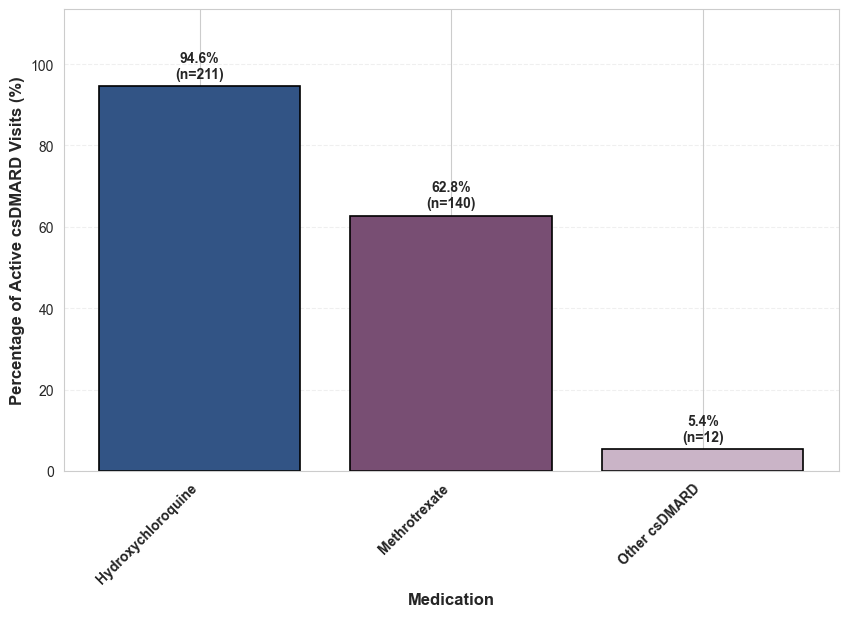

Total active csDMARD visits: 223
Hydroxychloroquine    94.618834
Methrotrexate         62.780269
Other csDMARD          5.381166
Name: count, dtype: float64


In [35]:
#Filter active csDMARD users and build medication list
main_drugs = ['Hydroxychloroquine', 'MTX']
df_active_csdmard = df_cleaned[df_cleaned['csdmard_use'] == 1].copy()

medications = []
for _, row in df_active_csdmard.iterrows():
    if row['mtx_use'] == 1:
        medications.append('Methrotrexate')
    drug = row['csdmard_name']
    if pd.notna(drug) and drug != 'none':
        medications.append(drug if drug in main_drugs else 'Other csDMARD')

#Calculate percentages
med_counts = pd.Series(medications).value_counts()
med_percentages = (med_counts / len(df_active_csdmard) * 100).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(med_percentages)), med_percentages.values,
               color=["#325485", "#784E73", "#CAB4C7"], edgecolor='black', linewidth=1.2)
# plt.title('Distribution of Active csDMARD Medications (including MTX)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Medication', fontsize=12, fontweight='bold')
plt.ylabel('Percentage of Active csDMARD Visits (%)', fontsize=12, fontweight='bold')
plt.ylim(0, med_percentages.max() * 1.2)
plt.xticks(range(len(med_percentages)), med_percentages.index, rotation=45, ha='right', fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')

for bar, pct, count in zip(bars, med_percentages.values, med_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f"{pct:.1f}%\n(n={count})", ha='center', fontweight='bold', fontsize=10)

plt.show()
print(f"Total active csDMARD visits: {len(df_active_csdmard)}\n{med_percentages}")

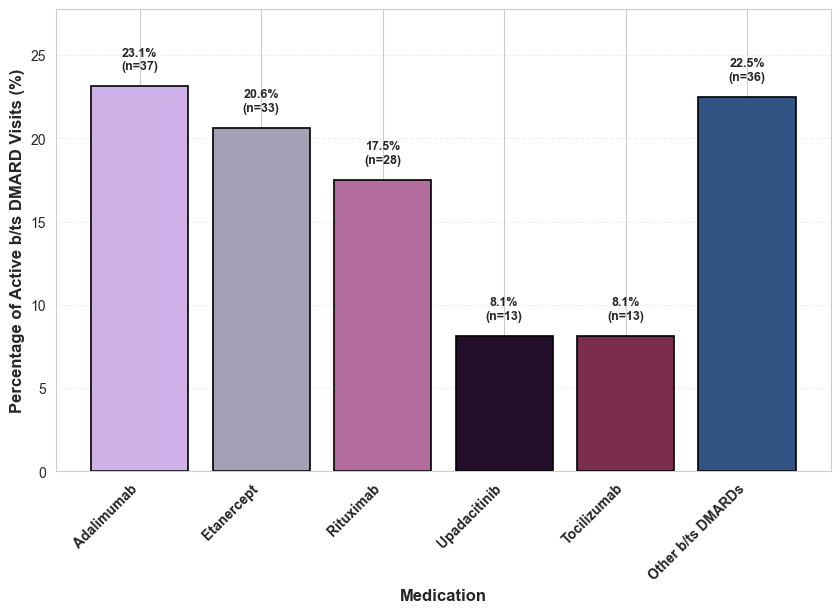

Total active b/ts DMARD visits: 160
Adalimumab           23.125
Etanercept           20.625
Rituximab            17.500
Upadacitinib          8.125
Tocilizumab           8.125
Other b/ts DMARDs    22.500
dtype: float64


In [36]:
#Filter active b/tsDMARD users
df_active_b_ts = df_cleaned[df_cleaned['b_ts_dmard_use'] == 1].copy()

medications_b_ts = []
for _, row in df_active_b_ts.iterrows():
    drug = row['b_ts_dmard_name']
    if pd.notna(drug) and drug != 'none':
        medications_b_ts.append(drug)

#Calculate counts and percentages
med_counts_b_ts = pd.Series(medications_b_ts).value_counts()
med_percentages_b_ts = (med_counts_b_ts / len(df_active_b_ts) * 100).sort_values(ascending=False)

#Keep top 5 medications, group the rest as "Other b/ts DMARDs"
top_n = 5
if len(med_percentages_b_ts) > top_n:
    top_meds = med_percentages_b_ts.head(top_n)
    other_count = med_counts_b_ts[top_n:].sum()
    other_pct = (other_count / len(df_active_b_ts) * 100)
    
    med_counts_b_ts = pd.concat([med_counts_b_ts.head(top_n), pd.Series({'Other b/ts DMARDs': other_count})])
    med_percentages_b_ts = pd.concat([top_meds, pd.Series({'Other b/ts DMARDs': other_pct})])

plt.figure(figsize=(10, 6))
palette_b_ts = ["#CEB1E7", "#A5A0B6", "#B26C9E", "#240D2B", "#7B2D4D", "#325485"]
bars = plt.bar(range(len(med_percentages_b_ts)), med_percentages_b_ts.values,
               color=palette_b_ts[:len(med_percentages_b_ts)], edgecolor='black', linewidth=1.2)
plt.xlabel('Medication', fontsize=12, fontweight='bold')
plt.ylabel('Percentage of Active b/ts DMARD Visits (%)', fontsize=12, fontweight='bold')
plt.ylim(0, med_percentages_b_ts.max() * 1.2)
plt.xticks(range(len(med_percentages_b_ts)), med_percentages_b_ts.index, rotation=45, ha='right', fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')

for bar, pct, count in zip(bars, med_percentages_b_ts.values, med_counts_b_ts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{pct:.1f}%\n(n={count})", ha='center', fontweight='bold', fontsize=9)

plt.show()
print(f"Total active b/ts DMARD visits: {len(df_active_b_ts)}\n{med_percentages_b_ts}")

In [37]:
#Define comorbidity column names
comorb_cols = [
    'comorb_cardiovascular', 
    'comorb_metabolic_endocrine', 
    'comorb_respiratory', 
    'comorb_renal_urological',
    'comorb_gastrointestinal_hepatic',
    'comorb_malignancy',
    'comorb_musculoskeletal',
    'comorb_neurologic_psychiatric',
    'comorb_autoimmune_other'
]

#Create mapping from column names to readable labels for visualization
comorb_label_map = {
    "comorb_cardiovascular": "Cardiovascular",
    "comorb_metabolic_endocrine": "Metabolic / Endocrine",
    "comorb_respiratory": "Respiratory",
    "comorb_renal_urological": "Renal / Urological",
    "comorb_gastrointestinal_hepatic": "Gastrointestinal / Hepatic",
    "comorb_malignancy": "Malignancy",
    "comorb_musculoskeletal": "Musculoskeletal",
    "comorb_neurologic_psychiatric": "Neurologic / Psychiatric",
    "comorb_autoimmune_other": "Autoimmune / Other"
}

# Calculate comorbidity prevalence at patient level. Group by patient and take max (since each patient can have multiple visits)
patient_comorb = df_cleaned.groupby('patient_id')[comorb_cols].max()

# Count total number of patients with each comorbidity, sorted in descending order
comorb_counts = patient_comorb.sum().sort_values(ascending=False)

# Calculate total number of unique patients
n_patients = patient_comorb.shape[0]

# Calculate percentage prevalence for each comorbidity
comorb_percent = (comorb_counts / n_patients * 100)

# Apply readable labels to the percentage and count data
comorb_percent_named = comorb_percent.rename(index=comorb_label_map)
comorb_counts_named = comorb_counts.rename(index=comorb_label_map)

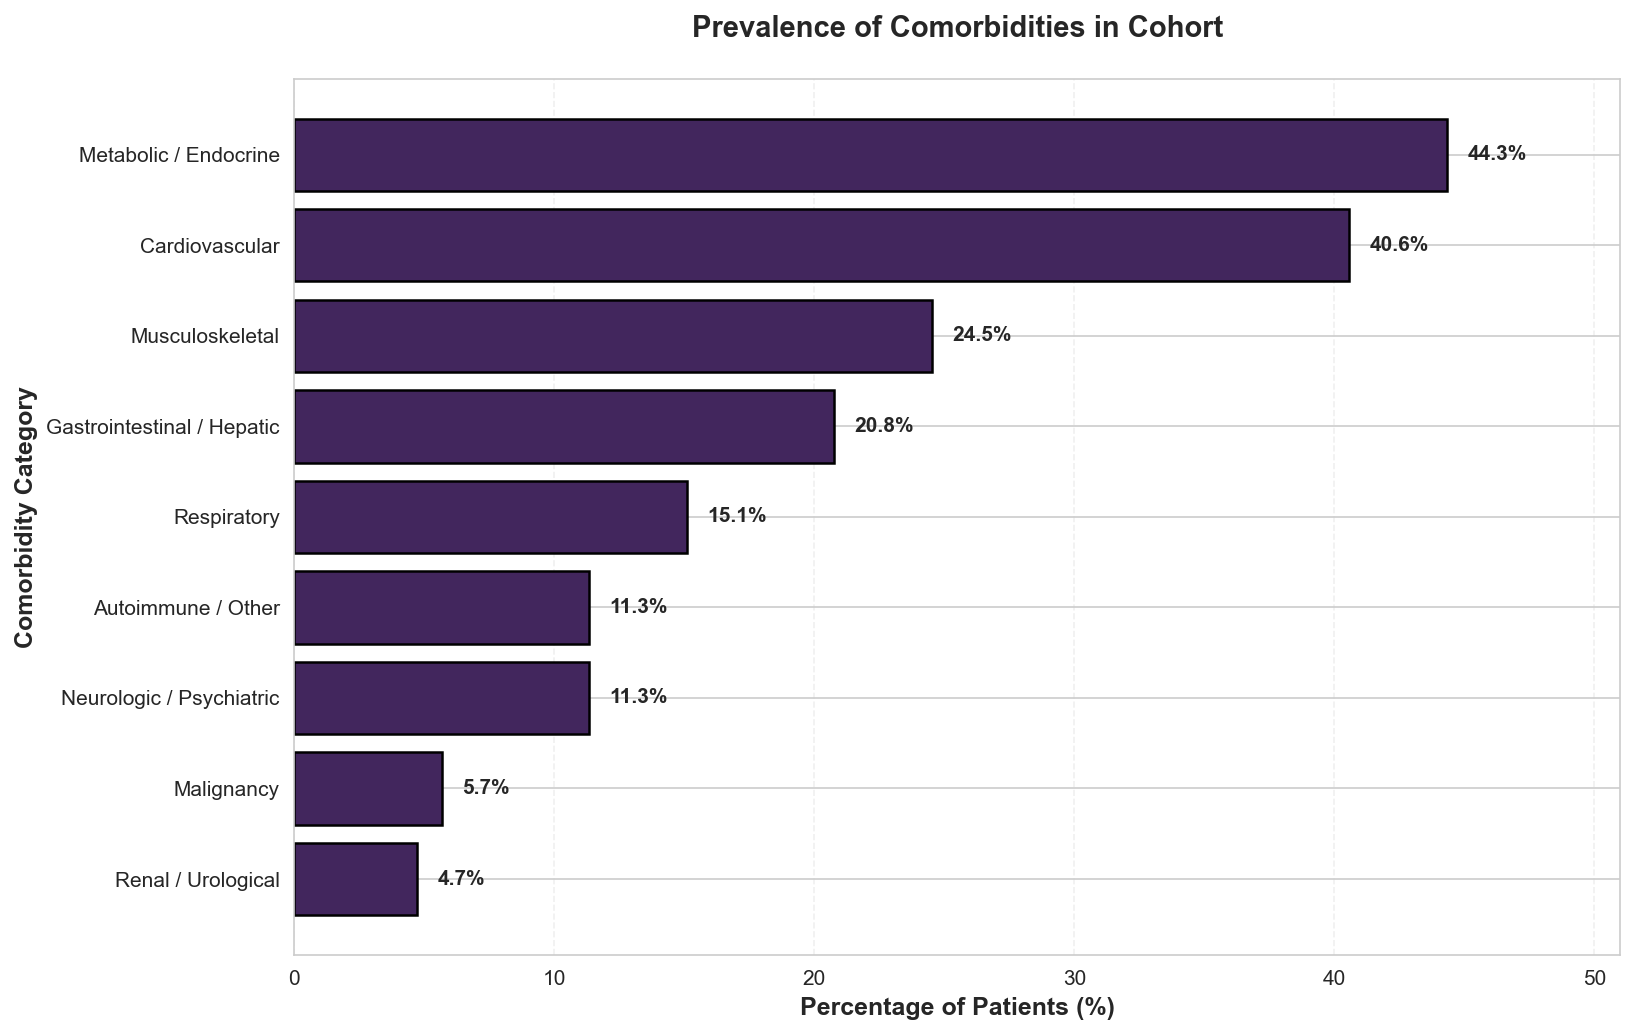

In [38]:
y_labels = comorb_percent_named.index.astype(str).to_list()
x_percent = comorb_percent_named.to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(11, 7), dpi=150)
graph = ax.barh(
    y_labels,
    x_percent,
    color='#42265D',
    edgecolor='black',
    linewidth=1.2
)

ax.set_title('Prevalence of Comorbidities in Cohort', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Percentage of Patients (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Comorbidity Category', fontsize=12, fontweight='bold')
ax.tick_params(axis='both', labelsize=10)

ax.set_xlim(0, max(x_percent) * 1.15)
ax.invert_yaxis()

# Add percentage labels on bars
for i, (p, pct) in enumerate(zip(graph, x_percent)):
    width = p.get_width()
    ax.text(
        width + 0.8,
        p.get_y() + p.get_height() / 2,
        f'{pct:.1f}%',
        ha='left',
        va='center',
        fontweight='bold',
        fontsize=10
    )

ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [39]:
df_cleaned['comorbidity_count'].describe()

count    393.000000
mean       2.267176
std        1.864646
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        7.000000
Name: comorbidity_count, dtype: float64

In [40]:
df_cleaned['treatment_decision_grouped'].value_counts(normalize=True, dropna=False) * 100

treatment_decision_grouped
escalation_or_switch    31.552163
baseline_no_decision    26.972010
stable_no_change        26.717557
tapering_or_stop        14.758270
Name: proportion, dtype: float64

In [41]:
df_cleaned['switch_reason'].value_counts(normalize=True, dropna=False) * 100

switch_reason
no_switch             92.111959
Inefficacy             7.124682
Adverse event          0.254453
Remission              0.254453
Patient preference     0.254453
Name: proportion, dtype: float64

## Bivariate Analysis
### Continuous variables

In [42]:
#Statistical comparison of continuous variables between flare groups
features_to_compare = {
    'das28_score': 'DAS28 Score',
    'das28_change': 'DAS28 Change',
    'log_esr': 'Log ESR',
    'log_crp_normalized': 'Log CRP',
    'age_at_visit': 'Age at Visit',
    'log_disease_duration': 'Log Disease Duration',
    'days_since_last_visit': 'Days Since Last Visit',
    'treatment_count': 'Treatment Count',
    'comorbidity_count': 'Comorbidity Count',
    'mtx_dose': 'MTX dose',
    'steroid_dose': 'Steroid dose'
}

comparison_results = []

for col, label in features_to_compare.items():
    #Split by flare status
    no_flare = df_cleaned[df_cleaned['flare_next_visit'] == 0][col].dropna()
    flare = df_cleaned[df_cleaned['flare_next_visit'] == 1][col].dropna()
    
    #Descriptive statistics
    no_flare_mean = no_flare.mean()
    no_flare_sd = no_flare.std()
    no_flare_median = no_flare.median()
    no_flare_q1 = no_flare.quantile(0.25)
    no_flare_q3 = no_flare.quantile(0.75)
    
    flare_mean = flare.mean()
    flare_sd = flare.std()
    flare_median = flare.median()
    flare_q1 = flare.quantile(0.25)
    flare_q3 = flare.quantile(0.75)
    
    #Mann-Whitney U test
    statistic, p_value = mannwhitneyu(no_flare, flare, alternative='two-sided')
    
    #Effect size (rank-biserial correlation)
    n1, n2 = len(no_flare), len(flare)
    r = 1 - (2*statistic) / (n1 * n2)  # rank-biserial correlation
    
    comparison_results.append({
        'Variable': label,
        'No Flare (Mean±SD)': f'{no_flare_mean:.2f}±{no_flare_sd:.2f}',
        'No Flare (Median[IQR])': f'{no_flare_median:.2f}[{no_flare_q1:.2f}-{no_flare_q3:.2f}]',
        'Flare (Mean±SD)': f'{flare_mean:.2f}±{flare_sd:.2f}',
        'Flare (Median[IQR])': f'{flare_median:.2f}[{flare_q1:.2f}-{flare_q3:.2f}]',
        'p-value': f'{p_value:.4f}',
        'Significant': 'Yes' if p_value < 0.05 else 'No',
        'Effect Size (r)': f'{r:.3f}'
    })

comparison_df = pd.DataFrame(comparison_results)
print("Mann-Whitney U Test Results: No Flare vs Flare at Next Visit")
print("="*140)
print(comparison_df.to_string(index=False))
print("\nNote: p-value < 0.05 indicates statistically significant difference")
print("Effect size r: |r| < 0.1 (negligible), 0.1-0.3 (small), 0.3-0.5 (medium), > 0.5 (large)")

Mann-Whitney U Test Results: No Flare vs Flare at Next Visit
             Variable No Flare (Mean±SD) No Flare (Median[IQR]) Flare (Mean±SD) Flare (Median[IQR]) p-value Significant Effect Size (r)
          DAS28 Score          3.09±1.12        3.04[2.20-3.73]       4.09±1.20     4.09[3.30-4.90]  0.0000         Yes           0.475
         DAS28 Change         -0.21±0.82       0.00[-0.35-0.00]      -0.00±0.92    0.00[-0.11-0.10]  0.0185         Yes           0.173
              Log ESR          2.87±0.78        2.89[2.20-3.44]       3.26±0.64     3.22[2.77-3.69]  0.0000         Yes           0.281
              Log CRP          0.60±0.53        0.47[0.18-0.83]       0.90±0.76     0.69[0.34-1.14]  0.0003         Yes           0.249
         Age at Visit        60.18±12.16     61.00[52.50-70.00]     58.85±12.44  57.00[50.00-68.75]  0.1978          No          -0.080
 Log Disease Duration          1.70±1.10        1.61[0.69-2.64]       1.91±1.18     2.08[0.69-2.88]  0.0856          No    

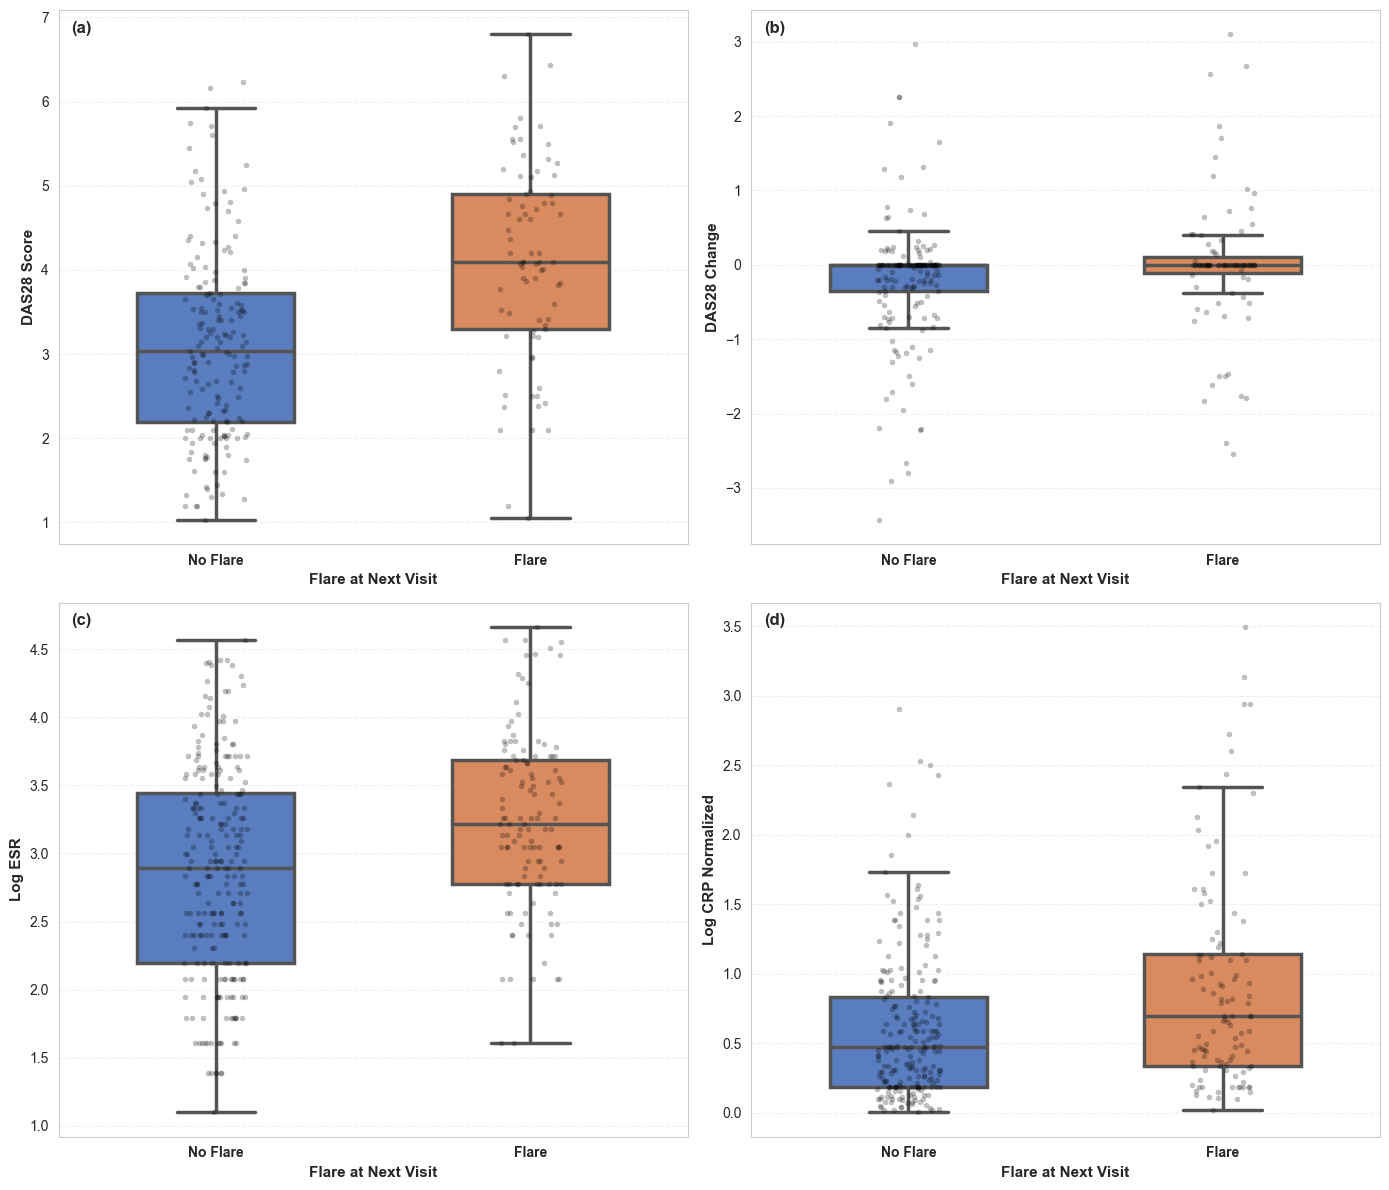

In [43]:
# Boxplots with p-values annotated on the plot
continuous_cols_stats = {
    'das28_score': 'DAS28 Score',
    'das28_change': 'DAS28 Change',
    'log_esr': 'Log ESR',
    'log_crp_normalized': 'Log CRP Normalized',
}

sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (col_name, col_label) in enumerate(continuous_cols_stats.items()):
    ax = axes[idx]
    
    # Boxplot
    sns.boxplot(
        data=df_cleaned, x='flare_next_visit', y=col_name,
        palette='muted', hue='flare_next_visit', width=0.5,
        linewidth=2.5, fliersize=0, ax=ax, legend=False)
    
    # Strip plot
    sns.stripplot(
        data=df_cleaned, x='flare_next_visit', y=col_name,
        color='black', alpha=0.25, size=4, jitter=True, ax=ax)
    
    # Calculate Mann-Whitney U test
    no_flare = df_cleaned[df_cleaned['flare_next_visit'] == 0][col_name].dropna()
    flare = df_cleaned[df_cleaned['flare_next_visit'] == 1][col_name].dropna()
    statistic, p_value = mannwhitneyu(no_flare, flare, alternative='two-sided')
    
    # Annotation
    ax.set_xlabel('Flare at Next Visit', fontsize=11, fontweight='bold')
    ax.set_ylabel(col_label, fontsize=11, fontweight='bold')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No Flare', 'Flare'], fontsize=10, fontweight='bold')
    ax.tick_params(axis='y', labelsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    
    # y_max = ax.get_ylim()[1]
    # ax.plot([0, 1], [y_max*0.95, y_max*0.95], 'k-', linewidth=1)
    # sig_marker = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'
    # ax.text(0.5, y_max*0.97, f'p={p_value:.4f} {sig_marker}', 
    #         ha='center', fontsize=10, fontweight='bold')
    

    ax.text(0.02, 0.98, f'({chr(97 + idx)})', transform=ax.transAxes, 
            fontsize=12, fontweight='bold', verticalalignment='top')

plt.tight_layout()
plt.show()

# print("\nSignificance Legend: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")

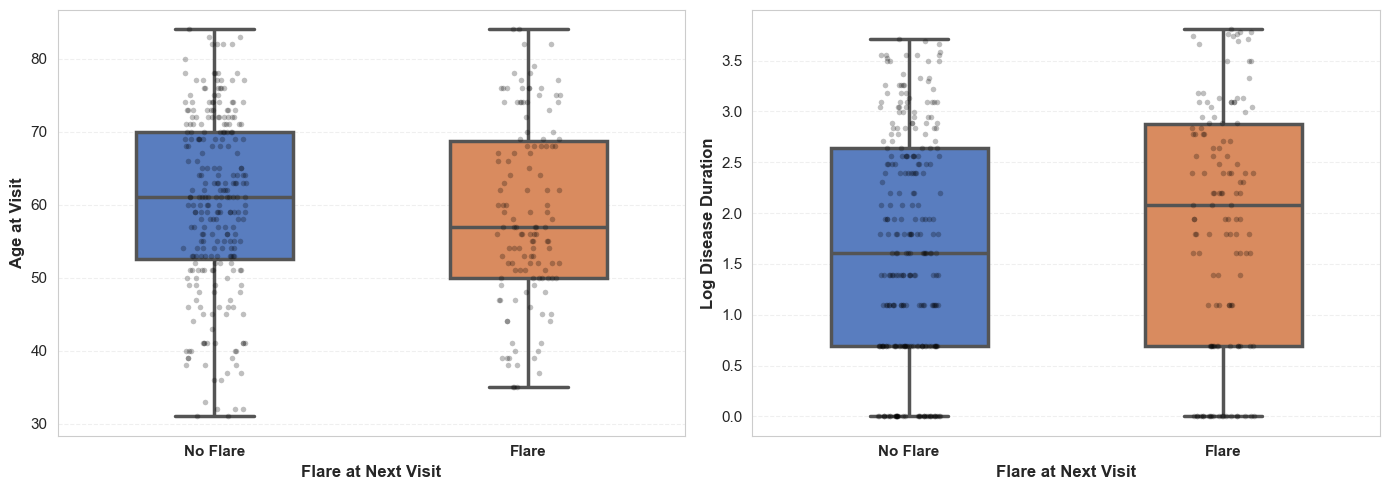

In [44]:
columns = {
'Age at Visit': df_cleaned['age_at_visit'],
'Log Disease Duration': df_cleaned['log_disease_duration']
}

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (col_name, col_data) in enumerate(columns.items()):
    ax = axes[idx]
    
    sns.boxplot(
        data=df_cleaned, x='flare_next_visit', y=col_data,
        palette='muted', hue='flare_next_visit', width=0.5,
        linewidth=2.5, fliersize=0, legend=False, ax=ax)
    
    # Add strip plot overlay for individual points
    sns.stripplot(
        data=df_cleaned, x='flare_next_visit', y=col_data,
        color='black', alpha=0.25, size=4, jitter=True, ax=ax)
    
    ax.set_xlabel('Flare at Next Visit', fontsize=12, fontweight='bold')
    ax.set_ylabel(col_name, fontsize=12, fontweight='bold')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No Flare', 'Flare'], fontsize=11, fontweight='bold')
    ax.tick_params(axis='y', labelsize=11)
    
    # Add grid for better readability
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


--- Feature Importance Scores ---
steroid_dose            0.8943
steroid_dose_category   0.0793
steroid_use             0.0264

Conclusion: The feature with the highest score is the one the algorithm finds most useful.


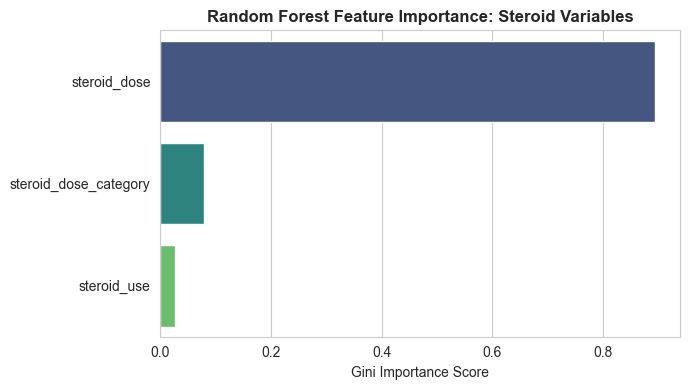

In [45]:
from sklearn.ensemble import RandomForestClassifier

# 1. Define the contenders and the target
# (Make sure 'flare_next_visit' matches your exact target column name)
mtx_features = ['steroid_dose', 'steroid_dose_category', 'steroid_use']
target = 'flare_next_visit' 

# 2. Create a temporary clean dataframe just for this test
# We drop rows with missing values to ensure a fair, error-free fight
temp_df = df_cleaned[mtx_features + [target]].dropna().copy()

# 3. Quick Encoding (Just in case 'mtx_dose_category' is still text like "Low"/"High")
if temp_df['steroid_dose_category'].dtype == 'object' or temp_df['steroid_dose_category'].dtype.name == 'category':
    temp_df['steroid_dose_category'] = pd.factorize(temp_df['steroid_dose_category'])[0]

X_temp = temp_df[mtx_features]
y_temp = temp_df[target]

# 4. Initialize and fit a simple, balanced Random Forest
rf_quick = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_quick.fit(X_temp, y_temp)

# 5. Extract and display the Feature Importances
importances = pd.Series(rf_quick.feature_importances_, index=mtx_features).sort_values(ascending=False)

print("--- Feature Importance Scores ---")
print(importances.to_string(float_format="%.4f"))
print("\nConclusion: The feature with the highest score is the one the algorithm finds most useful.")

# 6. Plot the results for a visual check
plt.figure(figsize=(7, 4), dpi=100)
sns.barplot(x=importances.values, y=importances.index, palette='viridis', hue=importances.index, legend=False)
plt.title('Random Forest Feature Importance: Steroid Variables', fontsize=12, fontweight='bold')
plt.xlabel('Gini Importance Score', fontsize=10)
plt.ylabel('')
plt.tight_layout()
plt.show()

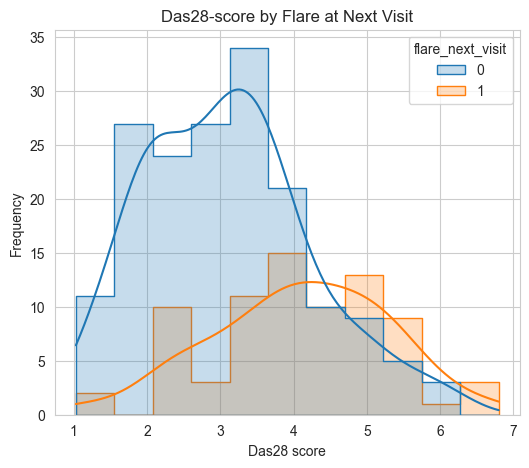

In [46]:
plt.figure(figsize=(6, 5))
sns.histplot(data=df_cleaned, x='das28_score', hue="flare_next_visit", kde=True, element="step")
plt.title(f'Das28-score by Flare at Next Visit')
plt.xlabel(f'Das28 score')
plt.ylabel('Frequency')
plt.show()

### Binary / Categorical variables



#### Demograhic

In [47]:
df_cleaned['age_bins'] = pd.cut(df_cleaned['age_at_visit'], bins=5, right=True)
df_cleaned['das28_bins'] = pd.cut(df_cleaned['das28_score'], bins=[0, 3.2, 5.1, 7], right=True)


target_cols = [
    'gender', 'age_bins'
]

for col in target_cols:
    raw_crosstab = pd.crosstab(df_cleaned[col], df_cleaned['flare_next_visit'])
    pct_crosstab = pd.crosstab(df_cleaned[col], df_cleaned['flare_next_visit'], normalize='index') * 100
    chi2, p, dof, expected = chi2_contingency(raw_crosstab)
    
    # Calculate Cramer's V (Effect Size)
    n = raw_crosstab.sum().sum()
    min_dim = min(raw_crosstab.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
    
    print(f"{col.upper()}")
    print(f"Header Row Stats -> Chi2: {chi2:.2f} | p-value: {p:.3f} | Cramer's V: {cramers_v:.3f}")
    
    for category in raw_crosstab.index:
        total_n = raw_crosstab.loc[category].sum()
        no_flare_n = raw_crosstab.loc[category, 0]
        no_flare_pct = pct_crosstab.loc[category, 0]
        flare_n = raw_crosstab.loc[category, 1]
        flare_pct = pct_crosstab.loc[category, 1]
        
        print(f"  Category {category} (Total N = {total_n}):")
        print(f"    No Flare -> {no_flare_n} ({no_flare_pct:.1f}%)")
        print(f"    Flare    -> {flare_n} ({flare_pct:.1f}%)")
    print("-" * 70)

GENDER
Header Row Stats -> Chi2: 0.16 | p-value: 0.689 | Cramer's V: 0.020
  Category 0 (Total N = 94):
    No Flare -> 65 (69.1%)
    Flare    -> 29 (30.9%)
  Category 1 (Total N = 299):
    No Flare -> 198 (66.2%)
    Flare    -> 101 (33.8%)
----------------------------------------------------------------------
AGE_BINS
Header Row Stats -> Chi2: 11.95 | p-value: 0.018 | Cramer's V: 0.174
  Category (30.947, 41.6] (Total N = 43):
    No Flare -> 29 (67.4%)
    Flare    -> 14 (32.6%)
  Category (41.6, 52.2] (Total N = 67):
    No Flare -> 37 (55.2%)
    Flare    -> 30 (44.8%)
  Category (52.2, 62.8] (Total N = 119):
    No Flare -> 81 (68.1%)
    Flare    -> 38 (31.9%)
  Category (62.8, 73.4] (Total N = 101):
    No Flare -> 79 (78.2%)
    Flare    -> 22 (21.8%)
  Category (73.4, 84.0] (Total N = 63):
    No Flare -> 37 (58.7%)
    Flare    -> 26 (41.3%)
----------------------------------------------------------------------


#### Clinical variables and Biomarkers

In [48]:
target_cols = [
    'rf_status', 'anti_ccp_status', 'previous_flare', 'das28_bins', 'inflammation_flag', 'visit_type'
]

for col in target_cols:
    # 1. Get raw counts (for Chi-Square and Table N)
    raw_crosstab = pd.crosstab(df_cleaned[col], df_cleaned['flare_next_visit'])
    
    # 2. Get percentages (multiplied by 100 for your Table)
    pct_crosstab = pd.crosstab(df_cleaned[col], df_cleaned['flare_next_visit'], normalize='index') * 100
    
    # 3. Calculate statistical tests
    chi2, p, dof, expected = chi2_contingency(raw_crosstab)
    
    # Calculate Cramer's V (Effect Size)
    n = raw_crosstab.sum().sum()
    min_dim = min(raw_crosstab.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
    
    print(f"{col.upper()}")
    print(f"Header Row Stats -> Chi2: {chi2:.2f} | p-value: {p:.3f} | Cramer's V: {cramers_v:.3f}")
    
    for category in raw_crosstab.index:
        total_n = raw_crosstab.loc[category].sum()
        no_flare_n = raw_crosstab.loc[category, 0]
        no_flare_pct = pct_crosstab.loc[category, 0]
        flare_n = raw_crosstab.loc[category, 1]
        flare_pct = pct_crosstab.loc[category, 1]
        
        print(f"  Category {category} (Total N = {total_n}):")
        print(f"    No Flare -> {no_flare_n} ({no_flare_pct:.1f}%)")
        print(f"    Flare    -> {flare_n} ({flare_pct:.1f}%)")
    print("-" * 70)

RF_STATUS
Header Row Stats -> Chi2: 0.12 | p-value: 0.727 | Cramer's V: 0.018
  Category 0 (Total N = 174):
    No Flare -> 119 (68.4%)
    Flare    -> 55 (31.6%)
  Category 1 (Total N = 216):
    No Flare -> 143 (66.2%)
    Flare    -> 73 (33.8%)
----------------------------------------------------------------------
ANTI_CCP_STATUS
Header Row Stats -> Chi2: 0.77 | p-value: 0.380 | Cramer's V: 0.044
  Category 0 (Total N = 127):
    No Flare -> 81 (63.8%)
    Flare    -> 46 (36.2%)
  Category 1 (Total N = 263):
    No Flare -> 181 (68.8%)
    Flare    -> 82 (31.2%)
----------------------------------------------------------------------
PREVIOUS_FLARE
Header Row Stats -> Chi2: 5.61 | p-value: 0.018 | Cramer's V: 0.120
  Category 0 (Total N = 257):
    No Flare -> 183 (71.2%)
    Flare    -> 74 (28.8%)
  Category 1 (Total N = 136):
    No Flare -> 80 (58.8%)
    Flare    -> 56 (41.2%)
----------------------------------------------------------------------
DAS28_BINS
Header Row Stats -> Chi

#### Treatments

In [49]:
target_cols = [
    'mtx_use', 'mtx_dose_category', 'steroid_use', 'steroid_dose_category', 'csdmard_use', 'b_ts_dmard_use', 'treatment_decision_grouped'
]

for col in target_cols:
    # 1. Get raw counts (for Chi-Square and Table N)
    raw_crosstab = pd.crosstab(df_cleaned[col], df_cleaned['flare_next_visit'])
    
    # 2. Get percentages (multiplied by 100 for your Table)
    pct_crosstab = pd.crosstab(df_cleaned[col], df_cleaned['flare_next_visit'], normalize='index') * 100
    
    # 3. Calculate statistical tests
    chi2, p, dof, expected = chi2_contingency(raw_crosstab)
    
    # Calculate Cramer's V (Effect Size)
    n = raw_crosstab.sum().sum()
    min_dim = min(raw_crosstab.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
    
    print(f"{col.upper()}")
    print(f"Header Row Stats -> Chi2: {chi2:.2f} | p-value: {p:.3f} | Cramer's V: {cramers_v:.3f}")
    
    for category in raw_crosstab.index:
        total_n = raw_crosstab.loc[category].sum()
        no_flare_n = raw_crosstab.loc[category, 0]
        no_flare_pct = pct_crosstab.loc[category, 0]
        flare_n = raw_crosstab.loc[category, 1]
        flare_pct = pct_crosstab.loc[category, 1]
        
        print(f"  Category {category} (Total N = {total_n}):")
        print(f"    No Flare -> {no_flare_n} ({no_flare_pct:.1f}%)")
        print(f"    Flare    -> {flare_n} ({flare_pct:.1f}%)")
    print("-" * 70)

MTX_USE
Header Row Stats -> Chi2: 0.05 | p-value: 0.819 | Cramer's V: 0.012
  Category 0 (Total N = 174):
    No Flare -> 118 (67.8%)
    Flare    -> 56 (32.2%)
  Category 1 (Total N = 219):
    No Flare -> 145 (66.2%)
    Flare    -> 74 (33.8%)
----------------------------------------------------------------------
MTX_DOSE_CATEGORY
Header Row Stats -> Chi2: 1.20 | p-value: 0.753 | Cramer's V: 0.055
  Category 0 mg (Total N = 175):
    No Flare -> 119 (68.0%)
    Flare    -> 56 (32.0%)
  Category 1-10 mg (Total N = 42):
    No Flare -> 29 (69.0%)
    Flare    -> 13 (31.0%)
  Category 11-20 mg (Total N = 150):
    No Flare -> 96 (64.0%)
    Flare    -> 54 (36.0%)
  Category 21-25 mg (Total N = 26):
    No Flare -> 19 (73.1%)
    Flare    -> 7 (26.9%)
----------------------------------------------------------------------
STEROID_USE
Header Row Stats -> Chi2: 1.01 | p-value: 0.315 | Cramer's V: 0.051
  Category 0 (Total N = 245):
    No Flare -> 169 (69.0%)
    Flare    -> 76 (31.0%)
  Ca

#### Comorbidities

In [50]:
target_cols = comorb_cols

for col in target_cols:
    # 1. Get raw counts (for Chi-Square and Table N)
    raw_crosstab = pd.crosstab(df_cleaned[col], df_cleaned['flare_next_visit'])
    
    # 2. Get percentages (multiplied by 100 for your Table)
    pct_crosstab = pd.crosstab(df_cleaned[col], df_cleaned['flare_next_visit'], normalize='index') * 100
    
    # 3. Calculate statistical tests
    chi2, p, dof, expected = chi2_contingency(raw_crosstab)
    
    # Calculate Cramer's V (Effect Size)
    n = raw_crosstab.sum().sum()
    min_dim = min(raw_crosstab.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
    
    print(f"{col.upper()}")
    print(f"Header Row Stats -> Chi2: {chi2:.2f} | p-value: {p:.3f} | Cramer's V: {cramers_v:.3f}")
    
    for category in raw_crosstab.index:
        total_n = raw_crosstab.loc[category].sum()
        no_flare_n = raw_crosstab.loc[category, 0]
        no_flare_pct = pct_crosstab.loc[category, 0]
        flare_n = raw_crosstab.loc[category, 1]
        flare_pct = pct_crosstab.loc[category, 1]
        
        print(f"  Category {category} (Total N = {total_n}):")
        print(f"    No Flare -> {no_flare_n} ({no_flare_pct:.1f}%)")
        print(f"    Flare    -> {flare_n} ({flare_pct:.1f}%)")
    print("-" * 70)

COMORB_CARDIOVASCULAR
Header Row Stats -> Chi2: 2.12 | p-value: 0.145 | Cramer's V: 0.073
  Category 0 (Total N = 251):
    No Flare -> 175 (69.7%)
    Flare    -> 76 (30.3%)
  Category 1 (Total N = 142):
    No Flare -> 88 (62.0%)
    Flare    -> 54 (38.0%)
----------------------------------------------------------------------
COMORB_METABOLIC_ENDOCRINE
Header Row Stats -> Chi2: 2.23 | p-value: 0.136 | Cramer's V: 0.075
  Category 0 (Total N = 241):
    No Flare -> 154 (63.9%)
    Flare    -> 87 (36.1%)
  Category 1 (Total N = 152):
    No Flare -> 109 (71.7%)
    Flare    -> 43 (28.3%)
----------------------------------------------------------------------
COMORB_RESPIRATORY
Header Row Stats -> Chi2: 0.82 | p-value: 0.365 | Cramer's V: 0.046
  Category 0 (Total N = 334):
    No Flare -> 220 (65.9%)
    Flare    -> 114 (34.1%)
  Category 1 (Total N = 59):
    No Flare -> 43 (72.9%)
    Flare    -> 16 (27.1%)
----------------------------------------------------------------------
COMORB_

In [51]:
for col in comorb_cols:
    
    print(f'{col}: {df_cleaned[col].mean() * 100}')


comorb_cardiovascular: 36.1323155216285
comorb_metabolic_endocrine: 38.67684478371501
comorb_respiratory: 15.012722646310433
comorb_renal_urological: 4.8346055979643765
comorb_gastrointestinal_hepatic: 27.480916030534353
comorb_malignancy: 3.0534351145038165
comorb_musculoskeletal: 29.262086513994912
comorb_neurologic_psychiatric: 10.178117048346055
comorb_autoimmune_other: 17.302798982188293


In [52]:
col=['crp_missing', 'esr_missing', 'das28_missing']
print(f'{col}: {df_cleaned[col].mean() * 100}')

['crp_missing', 'esr_missing', 'das28_missing']: crp_missing      17.048346
esr_missing       8.142494
das28_missing    34.096692
dtype: float64


C:\Users\konna\AppData\Local\Temp\ipykernel_21680\2905579004.py:12: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.boxplot(


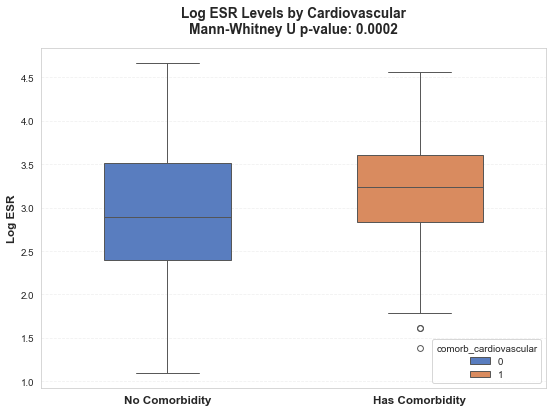

C:\Users\konna\AppData\Local\Temp\ipykernel_21680\2905579004.py:12: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.boxplot(


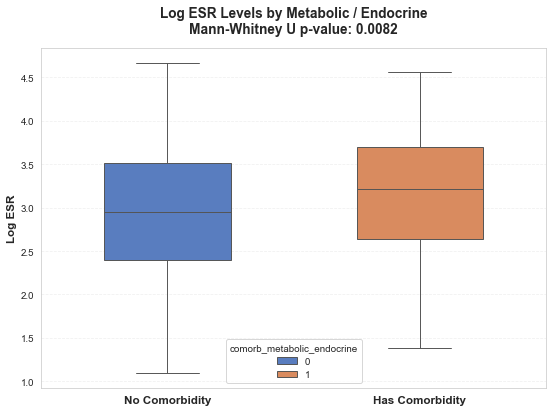

C:\Users\konna\AppData\Local\Temp\ipykernel_21680\2905579004.py:12: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.boxplot(


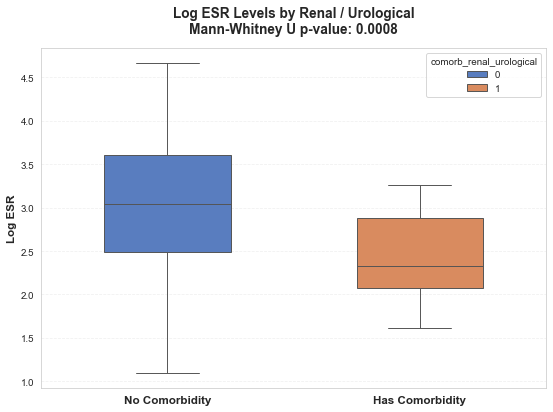

C:\Users\konna\AppData\Local\Temp\ipykernel_21680\2905579004.py:12: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.boxplot(


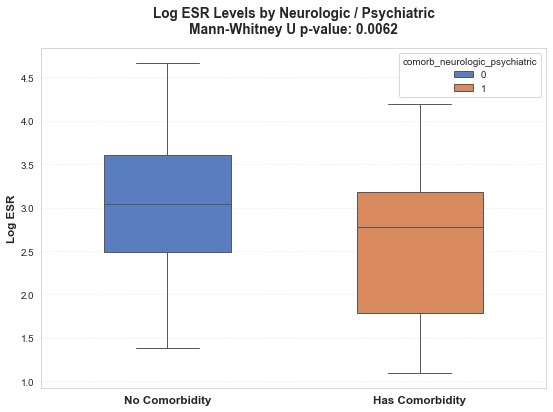

In [53]:
for col in comorb_cols:
    
    # Split the ESR data into two groups: those with the comorbidity, and those without
    esr_with = df_cleaned[df_cleaned[col] == 1]['log_esr'].dropna()
    esr_without = df_cleaned[df_cleaned[col] == 0]['log_esr'].dropna()

    # Run the Mann-Whitney U statistical test
    stat, p_val = mannwhitneyu(esr_with, esr_without)
    if p_val <0.05:
        # Generate a clean, professional Boxplot
        plt.figure(figsize=(8, 6), dpi=70)
        sns.boxplot(
            x=df_cleaned[col], 
            y=df_cleaned['log_esr'], 
            palette=sns.color_palette("muted"), 
            hue=df_cleaned[col],
            width=0.5
        )

        # Format the plot
        plt.title(f'Log ESR Levels by {comorb_label_map[col]}\nMann-Whitney U p-value: {p_val:.4f}', 
                fontsize=14, fontweight='bold', pad=15)
        plt.xticks([0, 1], ['No Comorbidity', 'Has Comorbidity'], fontsize=12, fontweight='bold')
        plt.xlabel('')
        plt.ylabel('Log ESR', fontsize=12, fontweight='bold')
        plt.grid(axis='y', alpha=0.3, linestyle='--')

        plt.tight_layout()
        plt.show()

C:\Users\konna\AppData\Local\Temp\ipykernel_21680\1187298624.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\konna\AppData\Local\Temp\ipykernel_21680\1187298624.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=0, fontsize=11)


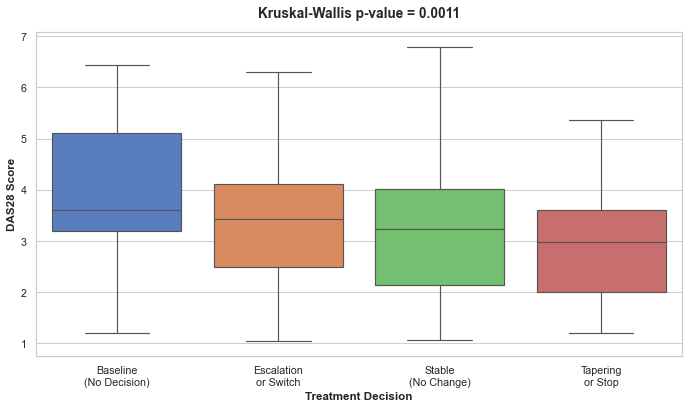

In [54]:
from scipy import stats
# 1. Calculate the Kruskal-Wallis p-value
# We drop NaNs to ensure the math works perfectly
groups = [group['das28_score'].dropna() for name, group in df_cleaned.groupby('treatment_decision_grouped')]
h_stat, p_value = stats.kruskal(*groups)

# 2. Set up the plot style to match your previous figures
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6), dpi=70)



# 3. Create the boxplot
# (Using 'muted' palette, but you can change it to match your exact color scheme)
sns.boxplot(
    data=df_cleaned, 
    x='treatment_decision_grouped', 
    y='das28_score',
    palette='muted',
    linewidth=1.2
)

# 4. Format Titles and Labels
# Automatically inserts the calculated p-value into the title!
if p_value < 0.001:
    title_p = "< 0.001"
else:
    title_p = f"= {p_value:.4f}"

plt.title(f'Kruskal-Wallis p-value {title_p}', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Treatment Decision', fontsize=12, fontweight='bold')
plt.ylabel('DAS28 Score', fontsize=12, fontweight='bold')

ax = plt.gca()
treatment_decision_labels = {
    'baseline_no_decision': 'Baseline\n(No Decision)',
    'escalation_or_switch': 'Escalation\nor Switch',
    'stable_no_change': 'Stable\n(No Change)',
    'tapering_or_stop': 'Tapering\nor Stop'}


old_labels = [item.get_text() for item in ax.get_xticklabels()]
new_labels = [treatment_decision_labels.get(label, label) for label in old_labels]

ax.set_xticklabels(new_labels, rotation=0, fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

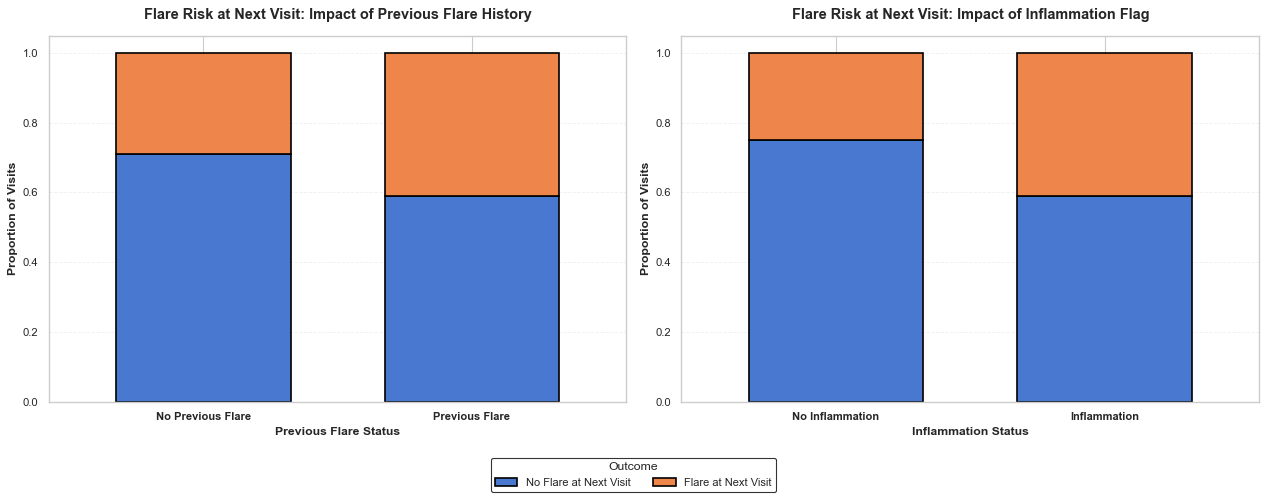

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=80)
prev_flare = pd.crosstab(
    df_cleaned['previous_flare'],
    df_cleaned['flare_next_visit'],
    normalize='index'
).round(2)
prev_flare.plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    color=sns.color_palette('muted', 2),
    edgecolor='black',
    linewidth=1.5,
    width=0.65
)

axes[0].set_title('Flare Risk at Next Visit: Impact of Previous Flare History',
             fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Previous Flare Status', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Proportion of Visits', fontsize=11, fontweight='bold')
axes[0].set_xticklabels(['No Previous Flare', 'Previous Flare'], rotation=0, fontsize=10, fontweight='bold')
axes[0].tick_params(axis='y', labelsize=10)

axes[0].grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
axes[0].set_axisbelow(True)
axes[0].set_ylim(0, 1.05)

if axes[0].get_legend(): axes[0].get_legend().remove()


infl_flag = pd.crosstab(
    df_cleaned['inflammation_flag'],
    df_cleaned['flare_next_visit'],
    normalize='index'
).round(2)

infl_flag.index = ["No Inflammation", "Inflammation"]
infl_flag.columns = ['No Flare at Next Visit', 'Flare at Next Visit']

infl_flag.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=sns.color_palette('muted', 2),
    edgecolor='black',
    linewidth=1.5,
    width=0.65
)

axes[1].set_title('Flare Risk at Next Visit: Impact of Inflammation Flag',
             fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Inflammation Status', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Proportion of Visits', fontsize=11, fontweight='bold')
axes[1].set_xticklabels(['No Inflammation', 'Inflammation'], rotation=0, fontsize=10, fontweight='bold')
axes[1].tick_params(axis='y', labelsize=10)

axes[1].grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
axes[1].set_axisbelow(True)
axes[1].set_ylim(0, 1.05)
# Ensure no local legend is drawn
if axes[1].get_legend(): axes[1].get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles, 
    ['No Flare at Next Visit', 'Flare at Next Visit'],
    title='Outcome',
    title_fontsize=11,
    fontsize=10,
    frameon=True,
    edgecolor='black',
    loc='lower center',          # Position at the lower center
    bbox_to_anchor=(0.5, -0.05), # Pull it slightly down below the plots
    ncol=2                       # Arrange the two legend items side-by-side horizontally
)

plt.tight_layout()

# 4. Manually shrink the bottom margin slightly to make room for the legend
fig.subplots_adjust(bottom=0.15) 

plt.show()

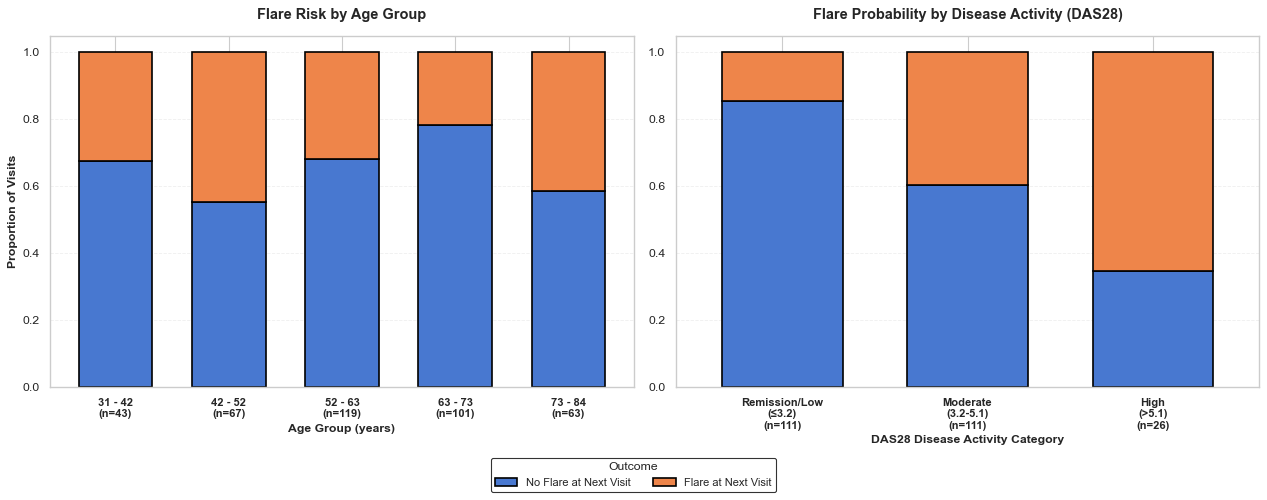

In [56]:
# 1. Create the binned columns
df_cleaned['age_bins'] = pd.cut(df_cleaned['age_at_visit'], bins=5, right=True)
df_cleaned['das28_bins'] = pd.cut(df_cleaned['das28_score'], bins=[0, 3.2, 5.1, 7], right=True)

# 2. Set up the 1x2 Figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=80)
colors = sns.color_palette('muted', 2) # Blue for No Flare, Magenta for Flare

counts_age = df_cleaned['age_bins'].value_counts().sort_index()
crosstab_age = pd.crosstab(df_cleaned['age_bins'], df_cleaned['flare_next_visit'], normalize='index')

labels_age = [f"{int(round(idx.left))} - {int(round(idx.right))}\n(n={int(count)})" 
              for idx, count in zip(counts_age.index, counts_age.values)]

crosstab_age.plot(kind='bar', stacked=True, ax=axes[0], color=colors, edgecolor='black', linewidth=1.5, width=0.65)

axes[0].set_title('Flare Risk by Age Group', fontsize=13, fontweight='bold', pad=15)
axes[0].set_ylabel('Proportion of Visits', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Age Group (years)', fontsize=11, fontweight='bold')
axes[0].set_xticklabels(labels_age, rotation=0, fontsize=10, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
axes[0].set_axisbelow(True)
axes[0].set_ylim(0, 1.05)
if axes[0].get_legend(): axes[0].get_legend().remove()

counts_das = df_cleaned['das28_bins'].value_counts().sort_index()
crosstab_das = pd.crosstab(df_cleaned['das28_bins'], df_cleaned['flare_next_visit'], normalize='index')

# Format EULAR labels (Using iloc to grab counts sequentially based on your cut bins)
labels_das = [
    f"Remission/Low\n(≤3.2)\n(n={counts_das.iloc[0]})",
    f"Moderate\n(3.2-5.1)\n(n={counts_das.iloc[1]})",
    f"High\n(>5.1)\n(n={counts_das.iloc[2]})"
]

crosstab_das.plot(kind='bar', stacked=True, ax=axes[1], color=colors, edgecolor='black', linewidth=1.5, width=0.65)

axes[1].set_title('Flare Probability by Disease Activity (DAS28)', fontsize=13, fontweight='bold', pad=15)
axes[1].set_ylabel('') # Left blank intentionally
axes[1].set_xlabel('DAS28 Disease Activity Category', fontsize=11, fontweight='bold')
axes[1].set_xticklabels(labels_das, rotation=0, fontsize=10, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
axes[1].set_axisbelow(True)
axes[1].set_ylim(0, 1.05)
if axes[1].get_legend(): axes[1].get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles, 
    ['No Flare at Next Visit', 'Flare at Next Visit'],
    title='Outcome',
    title_fontsize=11,
    fontsize=10,
    frameon=True,
    edgecolor='black',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05), # Anchor it below the plots
    ncol=2                       # Place side-by-side
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18) # Shrink bottom margin to fit legend perfectly
plt.show()

In [57]:
# df_cleaned['crp_bin'] = pd.cut(df_cleaned['log_crp_normalized'], bins=3)
# display(pd.crosstab(
#     df_cleaned['crp_bin'],
#     df_cleaned['flare_next_visit'],
#     rownames=['CRP Group'],
#     colnames=['Flare at Next Visit'],
#     normalize='index'
# ).round(2))
# display(pd.crosstab(df_cleaned['crp_bin'], df_cleaned['flare_next_visit'], 
#             rownames=['CRP Group'], colnames=['Flare at Next Visit']))
# chi2, p, dof, expected = chi2_contingency(pd.crosstab(df_cleaned['crp_bin'], df_cleaned['flare_next_visit']))
# print(f"Chi-Square Test for CRP Groups:")
# print(f"Chi2 Statistic: {chi2:.4f}, p-value: {p:.4f}")

In [58]:
# df_cleaned['esr_bin'] = pd.cut(df_cleaned['log_esr'], bins=3)
# display(pd.crosstab(
#     df_cleaned['esr_bin'],
#     df_cleaned['flare_next_visit'],
#     rownames=['ESR Group'],
#     colnames=['Flare at Next Visit'],
#     normalize='index'
# ).round(2))
# display(pd.crosstab(df_cleaned['esr_bin'], df_cleaned['flare_next_visit'], 
#             rownames=['ESR Group'], colnames=['Flare at Next Visit']))
# chi2, p, dof, expected = chi2_contingency(pd.crosstab(df_cleaned['esr_bin'], df_cleaned['flare_next_visit']))
# print(f"Chi-Square Test for ESR Groups:")
# print(f"Chi2 Statistic: {chi2:.4f}, p-value: {p}")


### Correlation matrix

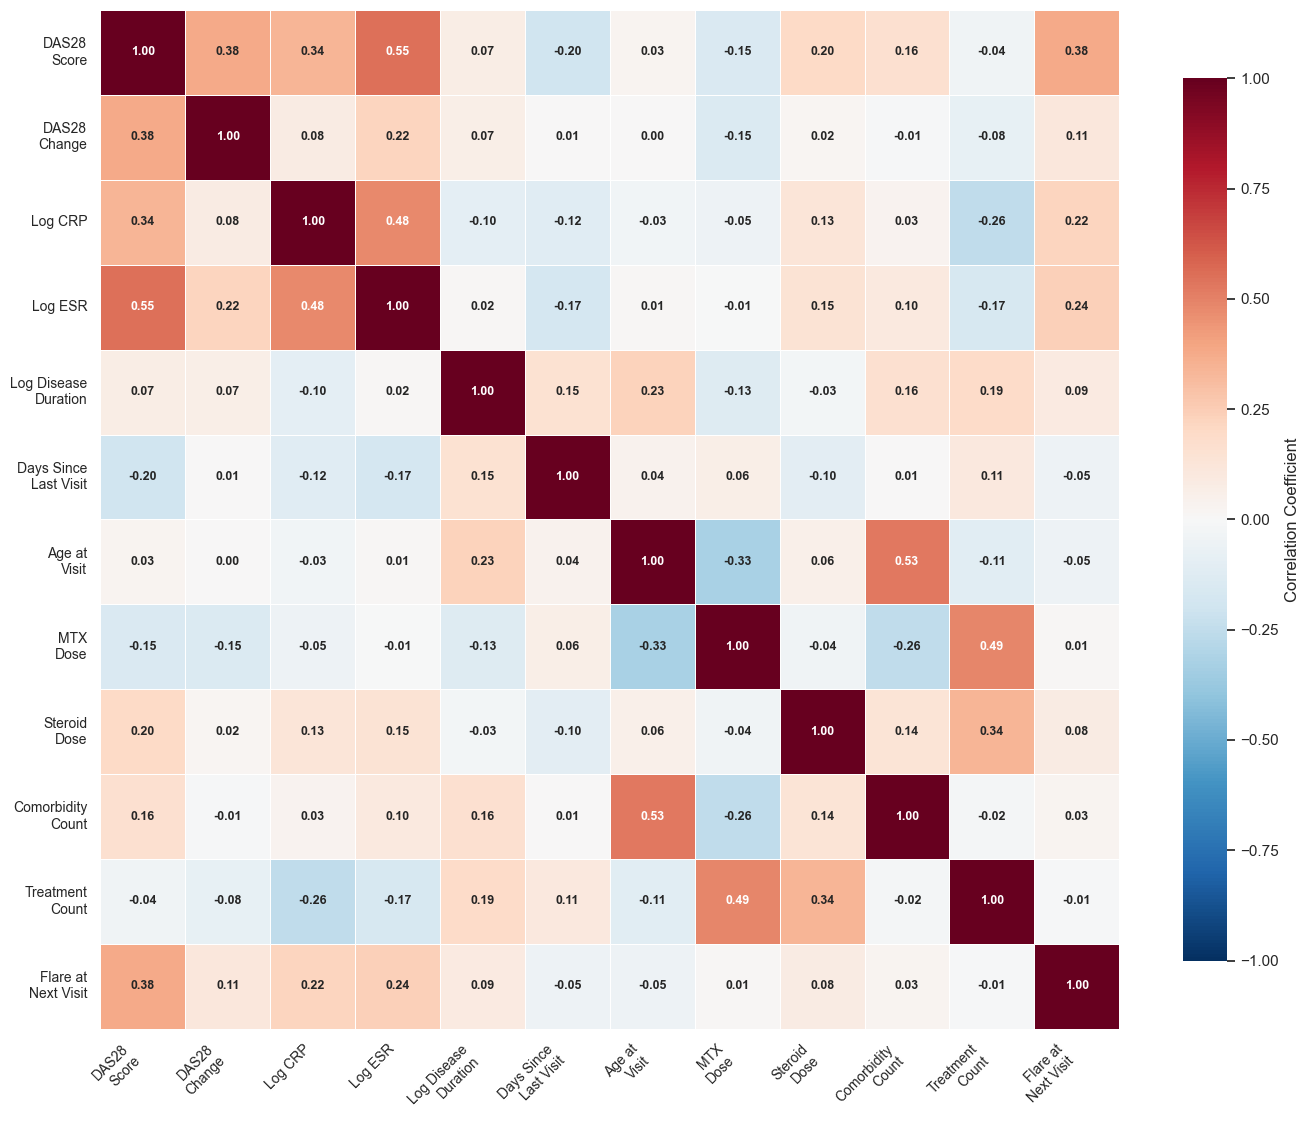

In [59]:
correlation_columns = [
    'das28_score', 'das28_change', 'log_crp_normalized', 'log_esr', 
    'log_disease_duration', 'days_since_last_visit',
    'age_at_visit', 'mtx_dose', 'steroid_dose', 
    'comorbidity_count', 'treatment_count',
    'flare_next_visit'
]

col_labels = [
    'DAS28\nScore',
    'DAS28\nChange',
    'Log CRP',
    'Log ESR',
    'Log Disease\nDuration',
    'Days Since\nLast Visit',
    'Age at\nVisit',
    'MTX\nDose',
    'Steroid\nDose',
    'Comorbidity\nCount',
    'Treatment\nCount',
    'Flare at\nNext Visit'
]

corr_matrix = df_cleaned[correlation_columns].corr()

fig, ax = plt.subplots(figsize=(14, 12), dpi=100)
sns.heatmap(
    corr_matrix,
    vmin=-1, vmax=1, center=0,
    cmap='RdBu_r',
    annot=True, 
    fmt='.2f',
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient', 'shrink': 0.8},
    xticklabels=col_labels,
    yticklabels=col_labels,
    ax=ax,
    annot_kws={'size': 9, 'fontweight': 'bold'}
)

# ax.set_title('Pearson Correlation Matrix: Clinical and Treatment Variables',
            #  fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

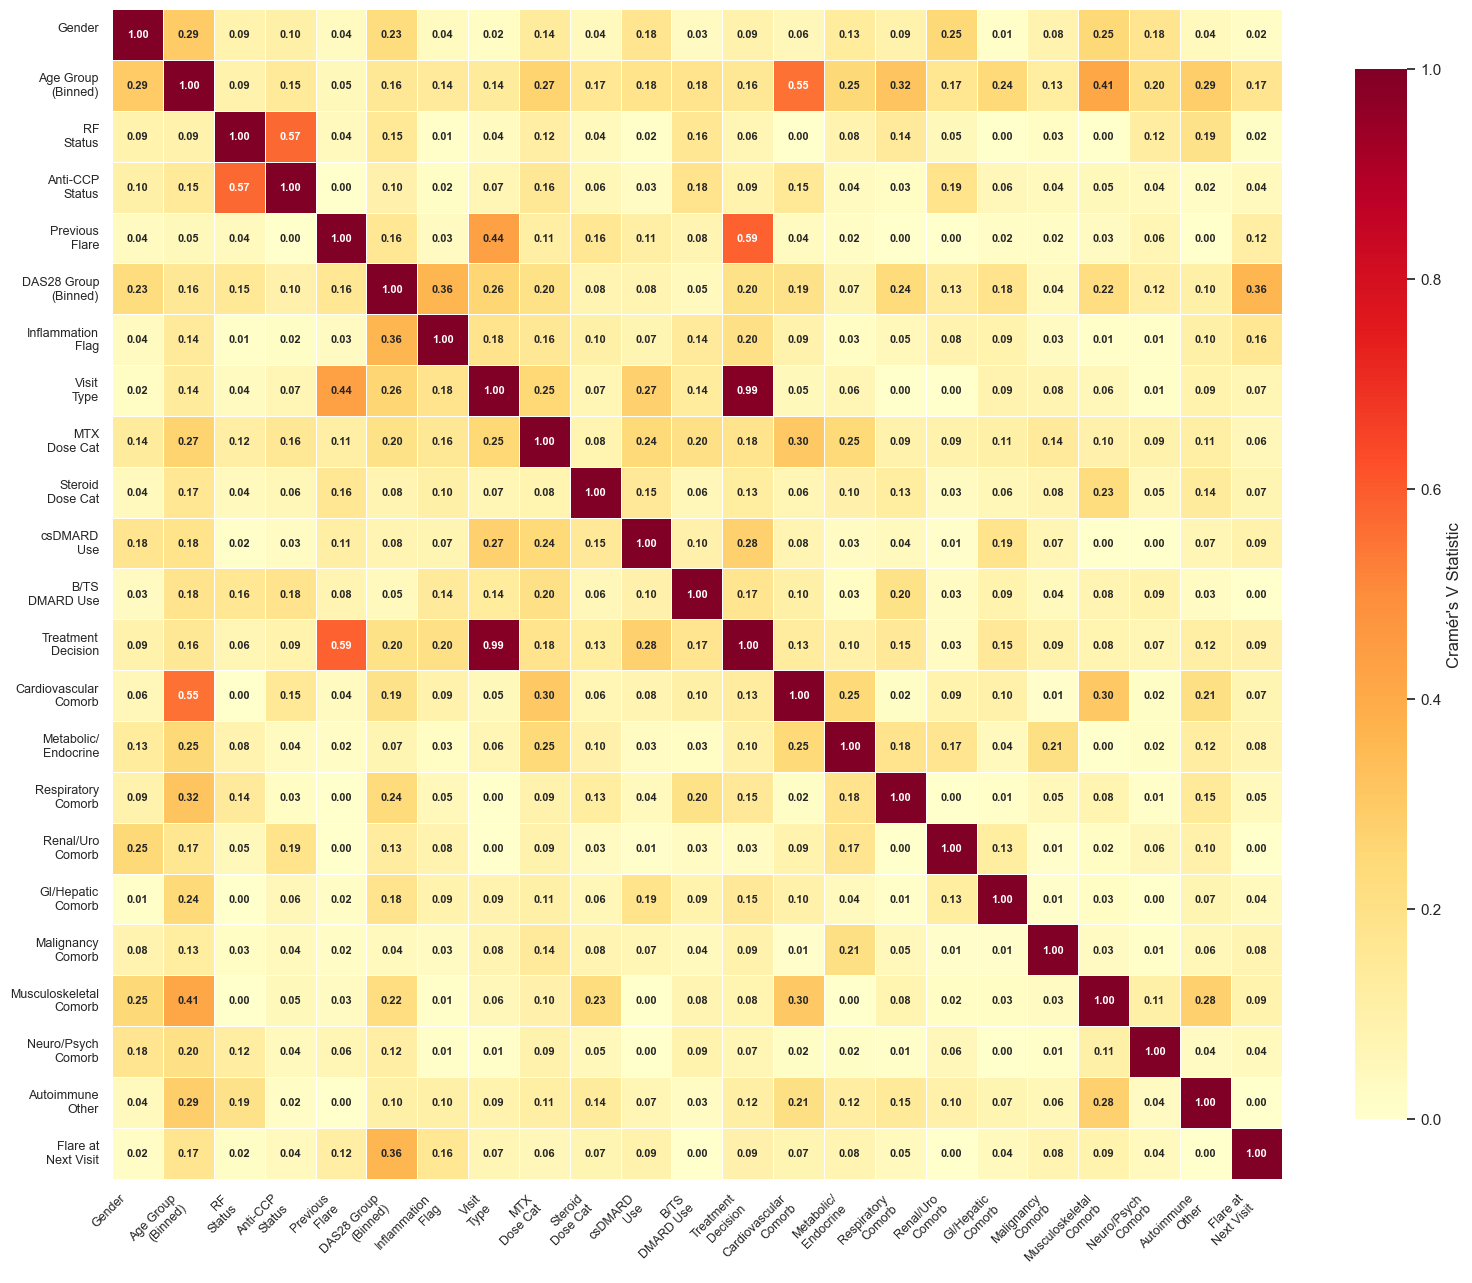

In [60]:
def cramers_v(x, y):
    """
    Calculate Cramér's V statistic for categorical-categorical association.
    V ranges from 0 to 1, with 0 indicating no association and 1 indicating perfect association.
    """
    # Create contingency table
    confusion_matrix = pd.crosstab(x, y)
    
    # Calculate chi-squared statistic
    chi2 = chi2_contingency(confusion_matrix)[0]
    
    # Get dimensions
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    
    # Avoid division by zero
    if min_dim == 0:
        return 0
    
    # Calculate Cramér's V
    v = np.sqrt(chi2 / (n * min_dim))
    
    return v


# Select categorical/binary features for the heatmap
categorical_columns = [
    'gender',  
    'age_bins',                
    'rf_status',                 
    'anti_ccp_status',  
    'previous_flare',
    'das28_bins',    
    'inflammation_flag',  
    'visit_type',
    'mtx_dose_category',
    'steroid_dose_category',
    'csdmard_use',            
    'b_ts_dmard_use',                       
    'treatment_decision_grouped',          
    'comorb_cardiovascular',    
    'comorb_metabolic_endocrine',
    'comorb_respiratory',
    'comorb_renal_urological',
    'comorb_gastrointestinal_hepatic',
    'comorb_malignancy',
    'comorb_musculoskeletal',
    'comorb_neurologic_psychiatric',
    'comorb_autoimmune_other',
    'flare_next_visit'          
]

cat_labels = [
    'Gender\n',
    'Age Group\n(Binned)',
    'RF\nStatus',
    'Anti-CCP\nStatus',
    'Previous\nFlare',
    'DAS28 Group\n(Binned)',
    'Inflammation\nFlag',
    'Visit\nType',
    'MTX\nDose Cat',
    'Steroid\nDose Cat',
    'csDMARD\nUse',
    'B/TS\nDMARD Use',
    'Treatment\nDecision',
    'Cardiovascular\nComorb',
    'Metabolic/\nEndocrine',
    'Respiratory\nComorb',
    'Renal/Uro\nComorb',
    'GI/Hepatic\nComorb',
    'Malignancy\nComorb',
    'Musculoskeletal\nComorb',
    'Neuro/Psych\nComorb',   
    'Autoimmune\nOther',
    'Flare at\nNext Visit'
]

# Calculate Cramér's V matrix
n_cat_vars = len(categorical_columns)
cramers_matrix = np.zeros((n_cat_vars, n_cat_vars))

for i, col1 in enumerate(categorical_columns):
    for j, col2 in enumerate(categorical_columns):
        if i == j:
            cramers_matrix[i, j] = 1.0
        else:
            cramers_matrix[i, j] = cramers_v(
                df_cleaned[col1].dropna(),
                df_cleaned[col2].dropna()
            )

# Convert to DataFrame for better visualization
cramers_df = pd.DataFrame(cramers_matrix, index=categorical_columns, columns=categorical_columns)

# Create heatmap
fig, ax = plt.subplots(figsize=(16, 14), dpi=100)
sns.heatmap(
    cramers_df,
    vmin=0, vmax=1, center=0.5,
    cmap='YlOrRd', 
    annot=True,
    fmt='.2f',
    square=True,
    linewidths=0.5,
    cbar_kws={'label': "Cramér's V Statistic", 'shrink': 0.8},
    xticklabels=cat_labels,
    yticklabels=cat_labels,
    ax=ax,
    annot_kws={'size': 8, 'fontweight': 'bold'}
)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()


In [61]:
from sklearn.feature_selection import mutual_info_classif

feature_cols = [ 
    'gender',
    'rf_status',
    'anti_ccp_status',
    'das28_score',
    'das28_change',
    'mtx_dose',
    'steroid_dose',
    'treatment_decision_grouped',
    'days_since_last_visit',
    'log_disease_duration',
    'age_at_visit',
    'previous_flare',
    'crp_missing',
    'esr_missing',
    'das28_missing',
    'log_crp_normalized',
    'log_esr',
    'comorbidity_count',
    'csdmard_use',
    'b_ts_dmard_use',
    'treatment_count',
    'comorb_cardiovascular', 
    'comorb_metabolic_endocrine', 
    'comorb_respiratory', 
    'comorb_gastrointestinal_hepatic',
    'comorb_musculoskeletal',
    'comorb_neurologic_psychiatric',
    'comorb_autoimmune_other'

]
X = df_cleaned[feature_cols].copy()
y = df_cleaned['flare_next_visit'].copy()

# Encode all object/category columns
for col in X.select_dtypes(include=['object', 'category']).columns:
    X[col], _ = pd.factorize(X[col])

# Convert bool to int
for col in X.select_dtypes(include='bool').columns:
    X[col] = X[col].astype(int)

# Simple imputation for MI exploration
for col in X.columns:
    if X[col].isna().any():
        if X[col].nunique(dropna=True) <= 10:
            X[col] = X[col].fillna(X[col].median())
        else:
            X[col] = X[col].fillna(X[col].median())

# # Make sure everything is numeric
# print(X.dtypes)

discrete_features = X.nunique() <= 10

mi_scores = mutual_info_classif(
    X, y,
    discrete_features=discrete_features,
    random_state=42
)

mi_scores = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
mi_scores.head(25)

C:\Users\konna\AppData\Local\Temp\ipykernel_21680\735372303.py:38: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include=['object', 'category']).columns:


age_at_visit                       4.551636e-02
steroid_dose                       3.928355e-02
log_esr                            3.719288e-02
das28_score                        3.158550e-02
comorbidity_count                  2.380570e-02
das28_change                       1.914472e-02
previous_flare                     7.725645e-03
treatment_count                    6.343028e-03
log_crp_normalized                 4.689769e-03
csdmard_use                        4.560677e-03
treatment_decision_grouped         4.485794e-03
comorb_musculoskeletal             4.400181e-03
comorb_metabolic_endocrine         3.304121e-03
comorb_cardiovascular              3.102076e-03
comorb_respiratory                 1.458258e-03
comorb_neurologic_psychiatric      1.193154e-03
anti_ccp_status                    1.056296e-03
comorb_gastrointestinal_hepatic    1.030551e-03
crp_missing                        8.194657e-04
esr_missing                        5.040264e-04
rf_status                          3.883

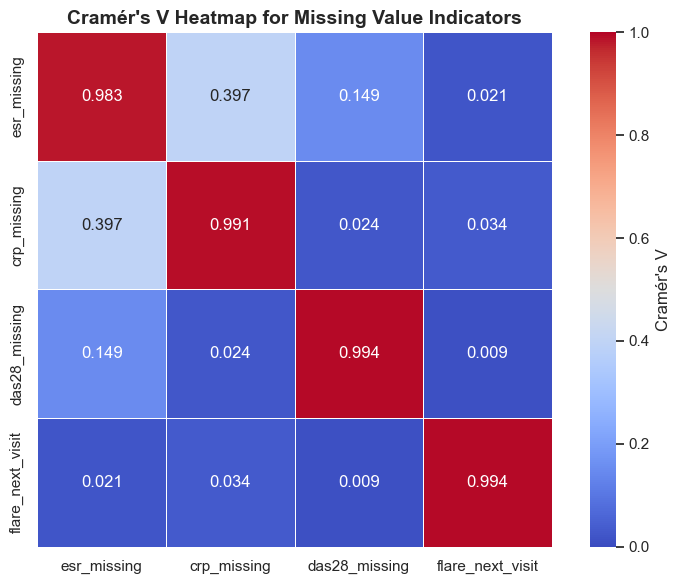

In [62]:
def cramers_v(var1, var2):
    """Calculate Cramér's V statistic for categorical-categorical association."""
    confusion_matrix = pd.crosstab(var1, var2)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    if min_dim == 0:
        return 0
    return np.sqrt(chi2 / (n * min_dim))

# Select the three variables
variables = ['esr_missing', 'crp_missing', 'das28_missing','flare_next_visit']
data_subset = df_cleaned[variables].copy()

# Create Cramér's V matrix
cramers_matrix = pd.DataFrame(
    np.zeros((len(variables), len(variables))),
    index=variables,
    columns=variables
)

for i, var1 in enumerate(variables):
    for j, var2 in enumerate(variables):
        cramers_matrix.iloc[i, j] = cramers_v(data_subset[var1], data_subset[var2])

# Create heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cramers_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            vmin=0, vmax=1, cbar_kws={'label': "Cramér's V"},
            square=True, linewidths=0.5)
plt.title("Cramér's V Heatmap for Missing Value Indicators", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Presentation

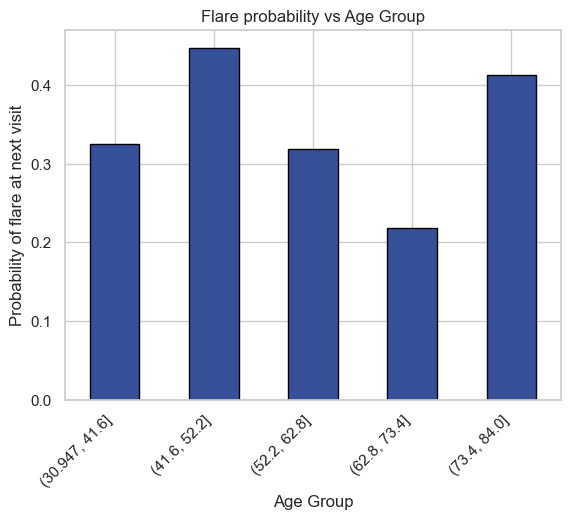

In [63]:
flare_rate = df_cleaned.groupby('age_bins')['flare_next_visit'].mean()
flare_rate.plot(kind='bar', color="#36509A", edgecolor='black')

plt.title("Flare probability vs Age Group")
plt.ylabel("Probability of flare at next visit")
plt.xlabel("Age Group")
plt.xticks(rotation=45, ha='right')
plt.show()

In [64]:
# # Define a reusable function for binned analysis
# def analyze_binned_variable(df, column, bins, var_name, plot=True):
#     """Analyze a continuous variable by binning it."""
#     bin_col = f'{column}_binned'
#     df[bin_col] = pd.cut(df[column], bins=bins)
    
#     # Chi-square test
#     ct = pd.crosstab(df[bin_col], df['flare_next_visit'])
#     chi2, p, dof, expected = chi2_contingency(ct)
    
#     # Display tables and stats
#     print(f"\n{'='*60}")
#     print(f"{var_name} Analysis")
#     print(f"{'='*60}")
#     display(pd.crosstab(df[bin_col], df['flare_next_visit'], normalize='index', 
#                         rownames=[f'{var_name} Group'], colnames=['Flare at Next Visit']).round(2))
#     display(ct)
#     print(f"Chi-Square Test: χ² = {chi2:.4f}, p-value = {p:.4f}\n")
    
#     # Plot if requested
#     if plot:
#         flare_rate = df.groupby(bin_col)['flare_next_visit'].mean()
#         flare_rate.plot(kind='bar', color="#36509A", edgecolor='black', figsize=(8, 5))
#         plt.title(f"Flare Probability vs {var_name}")
#         plt.ylabel("Probability of Flare at Next Visit")
#         plt.xlabel(f"{var_name} Range")
#         plt.xticks(rotation=45, ha='right')
#         plt.tight_layout()
#         plt.show()

# # Apply to all binned variables
# analyze_binned_variable(df_cleaned, 'age_at_visit', 5, 'Age at Visit')
# analyze_binned_variable(df_cleaned, 'das28_score', 3, 'DAS28 Score')
# analyze_binned_variable(df_cleaned, 'log_crp_normalized', 3, 'Log CRP')
# analyze_binned_variable(df_cleaned, 'log_esr', 3, 'Log ESR')

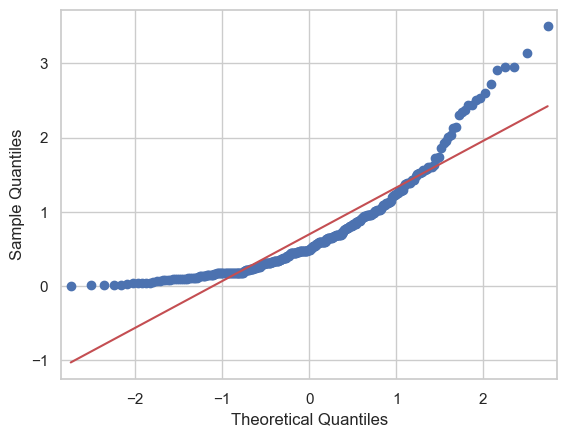

In [65]:
import statsmodels.api as sm
import pylab as py

sm.qqplot(df_cleaned['log_crp_normalized'].dropna(), line='s')
py.show()

In [66]:
df_cleaned.to_pickle('data_cleaned.pkl')